# Hier-COS Output Analysis

This notebook analyzes seeded training/test artifacts in `/scratch/g.saggini1/outputs/` and compares Hier-COS variants across datasets. Each experiment is a parent directory containing `seed_<seed>` runs; curves and final metrics report the mean and sample standard deviation across those seeds.

Default setup:
- baselines: `hiercos_<dataset>_global_softmax_ce_reg_baseline_<weight>` with `equal` and `kl_leaf`
- orthogonalize-all lex runs: `hiercos_<dataset>_global_softmax_ce_reg_lex_orthogonalize_all_<mode>`
- conflict-only lex runs: `hiercos_<dataset>_global_softmax_ce_reg_lex_conflict_only_<mode>`
- coarse-first transform ablations: `hiercos_<dataset>_global_softmax_ce_reg_lex_orthogonalize_all_coarse_first_transform_<transform>`
- targeted normalization ablation: run with `model.loss=level_softmax_ce_reg` using explicit output directories

It includes:
- validation curves for `FPA`, `weighted AP`, `TICE`, and `AHD`,
- per-level validation top-down/independent accuracy curves,
- training loss comparisons (`total`, `ce`, `reg`, `kl`, and exact weighted `loss_level_*` when available),
- optional projection/gradient diagnostics when those metrics are present in logs,
- final test comparison tables with deltas versus dataset baseline.


In [11]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
repo_root = cwd if (cwd / 'configs').exists() else cwd.parent
notebook_utils_dir = repo_root / 'notebooks'
if str(notebook_utils_dir) not in sys.path:
    sys.path.insert(0, str(notebook_utils_dir))

from hcast_analysis_utils import (
    HCastAnalysis as HierCosAnalysis,
    HCastAnalysisConfig as HierCosAnalysisConfig,
    resolve_project_root,
)

PROJECT_ROOT = resolve_project_root()
OUTPUTS_ROOT = Path('/scratch/g.saggini1/outputs')
print(f'Using project root: {PROJECT_ROOT}')


Using project root: /home/g.saggini1/lexicographic_deep_learning_detailed_study


In [12]:
INCLUDE_BASELINES = True
BASELINE_COLOR = "#243ab4"

BASELINE_BY_DATASET = {
    'cifar-100': {'run_dir': 'hiercos_cifar100_global_softmax_ce_reg_baseline_kl_leaf', 'label': 'Hier-COS global softmax kl_leaf baseline'},
    'cub-200-2011': {'run_dir': 'hiercos_cub200_global_softmax_ce_reg_baseline_kl_leaf', 'label': 'Hier-COS global softmax kl_leaf baseline'},
    'fgvc-aircraft': {'run_dir': 'hiercos_aircraft_global_softmax_ce_reg_baseline_kl_leaf', 'label': 'Hier-COS global softmax kl_leaf baseline'},
    'inat19': {'run_dir': 'hiercos_inat19_global_softmax_ce_reg_baseline_kl_leaf', 'label': 'Hier-COS global softmax kl_leaf baseline'},
}

MANUAL_RUNS = [
    # Equal-weight non-lex baselines
    # {'run_dir': 'hiercos_cifar100_global_softmax_ce_reg_baseline_equal', 'label': 'Hier-COS global softmax equal baseline'},
    # {'run_dir': 'hiercos_cub200_global_softmax_ce_reg_baseline_equal', 'label': 'Hier-COS global softmax equal baseline'},
    # {'run_dir': 'hiercos_aircraft_global_softmax_ce_reg_baseline_equal', 'label': 'Hier-COS global softmax equal baseline'},
    # {'run_dir': 'hiercos_inat19_global_softmax_ce_reg_baseline_equal', 'label': 'Hier-COS global softmax equal baseline'},

    
    # level-softmax-ce-reg
    # {'run_dir': 'hiercos_cifar100_level_softmax_ce_reg_baseline_kl_leaf', 'label': 'Hier-COS level softmax kl_leaf baseline'},
    # {'run_dir': 'hiercos_cub200_level_softmax_ce_reg_baseline_kl_leaf', 'label': 'Hier-COS level softmax kl_leaf baseline'},
    # {'run_dir': 'hiercos_aircraft_level_softmax_ce_reg_baseline_kl_leaf', 'label': 'Hier-COS level softmax kl_leaf baseline'},
    # {'run_dir': 'hiercos_inat19_level_softmax_ce_reg_baseline_kl_leaf', 'label': 'Hier-COS level softmax kl_leaf baseline'},
    
    {'run_dir': 'hiercos_cifar100_global_softmax_ce_reg_baseline_kl_leaf_identity', 'label': 'Hier-COS global softmax kl_leaf_identity baseline'},
    {'run_dir': 'hiercos_cub200_global_softmax_ce_reg_baseline_kl_leaf_identity', 'label': 'Hier-COS global softmax kl_leaf_identity baseline'},
    {'run_dir': 'hiercos_aircraft_global_softmax_ce_reg_baseline_kl_leaf_identity', 'label': 'Hier-COS global softmax kl_leaf_identity baseline'},
    {'run_dir': 'hiercos_inat19_global_softmax_ce_reg_baseline_kl_leaf_identity', 'label': 'Hier-COS global softmax kl_leaf baseline'},
    # level-softmax-ce-reg identity
    # {'run_dir': 'hiercos_cifar100_level_softmax_ce_reg_baseline_kl_leaf_identity', 'label': 'Hier-COS level softmax kl_leaf_identity baseline'},
    # {'run_dir': 'hiercos_cub200_level_softmax_ce_reg_baseline_kl_leaf_identity', 'label': 'Hier-COS level softmax kl_leaf_identity baseline'},
    # {'run_dir': 'hiercos_aircraft_level_softmax_ce_reg_baseline_kl_leaf_identity', 'label': 'Hier-COS level softmax kl_leaf_identity baseline'},
    # {'run_dir': 'hiercos_inat19_level_softmax_ce_reg_baseline_kl_leaf_identity', 'label': 'Hier-COS level softmax kl_leaf baseline'},

    # global-softmax Orthogonalize-all lex runs 
    *[
        {'run_dir': f'hiercos_{dataset}_global_softmax_ce_reg_lex_orthogonalize_all_{mode}',
         'label': f'Hier-COS global softmax {mode} orthogonalize_all'}
        for dataset in ('cifar100', 'cub200', 'aircraft', 'inat19')
        for mode in ('coarse_first', '')
    ],
    *[
        {'run_dir': f'hiercos_{dataset}_global_softmax_ce_reg_lex_orthogonalize_all_{mode}_identity',
         'label': f'Hier-COS global softmax {mode} orthogonalize_all identity'}
        for dataset in ('cifar100', 'cub200', 'aircraft', 'inat19')
        for mode in ('coarse_first', '')
    ],
    # *[
    #     {'run_dir': f'hiercos_{dataset}_global_softmax_ce_reg_lex_orthogonalize_all_{mode}_kl_leaf',
    #      'label': f'Hier-COS global softmax {mode} orthogonalize_all kl_leaf'}
    #     for dataset in ('cifar100', 'cub200', 'aircraft', 'inat19')
    #     for mode in ('coarse_first', '')
    # ],
    # level-softmax Orthogonalize-all lex runs
    # *[
    #     {'run_dir': f'hiercos_{dataset}_level_softmax_ce_reg_lex_orthogonalize_all_{mode}',
    #      'label': f'Hier-COS level softmax {mode} orthogonalize_all'}
    #     for dataset in ('cifar100', 'cub200', 'aircraft', 'inat19')
    #     for mode in ('coarse_first', '')
    # ],
    # *[
    #     {'run_dir': f'hiercos_{dataset}_level_softmax_ce_reg_lex_orthogonalize_all_{mode}_identity',
    #      'label': f'Hier-COS level softmax {mode} orthogonalize_all identity'}
    #     for dataset in ('cifar100', 'cub200', 'aircraft', 'inat19')
    #     for mode in ('coarse_first', '')
    # ],
    # *[
    #     {'run_dir': f'hiercos_{dataset}_level_softmax_ce_reg_lex_orthogonalize_all_{mode}_kl_leaf',
    #      'label': f'Hier-COS level softmax {mode} orthogonalize_all kl_leaf'}
    #     for dataset in ('cub200', 'aircraft')
    #     for mode in ('coarse_first', '')
    # ],

    # # Conflict-only lex runs
    # *[
    #     {'run_dir': f'hiercos_{dataset}_global_softmax_ce_reg_lex_conflict_only_{mode}',
    #      'label': f'Hier-COS global softmax {mode} conflict_only'}
    #     for dataset in ('cifar100', 'cub200', 'aircraft', 'inat19')
    #     for mode in ('coarse_first', 'fine_first')
    # ],

    # Uncomment after running transform ablations.
    # *[
    #     {'run_dir': f'hiercos_{dataset}_global_softmax_ce_reg_lex_orthogonalize_all_coarse_first_{transform}',
    #      'label': f'Hier-COS global softmax coarse_first {transform}'}
    #     for dataset in ('cifar100', 'cub200', 'aircraft', 'inat19')
    #     for transform in ('bn_linear', 'final_only')
    # ],
    # *[
    #     {'run_dir': f'hiercos_{dataset}_level_softmax_ce_reg_lex_orthogonalize_all_coarse_first_{transform}_kl_leaf_identity',
    #      'label': f'Hier-COS level softmax coarse_first {transform} identity'}
    #     for dataset in ('cifar100', 'cub200', 'aircraft', 'inat19')
    #     for transform in ('', 'final_only')
    # ],
]

TEMPERATURE_COLOR_PALETTE = [
    '#d62728',
    '#2ca02c',
    '#ff7f0e',
    '#9467bd',
    '#8c564b',
    '#17becf',
    '#e377c2',
    '#bcbd22',
]


In [13]:
config = HierCosAnalysisConfig(
    outputs_root=OUTPUTS_ROOT,
    include_baselines=INCLUDE_BASELINES,
    baseline_color=BASELINE_COLOR,
    baseline_by_dataset=BASELINE_BY_DATASET,
    manual_runs=MANUAL_RUNS,
    temperature_color_palette=TEMPERATURE_COLOR_PALETTE,
)

analysis = HierCosAnalysis.from_config(config)
analysis.print_run_summary()


Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hiercos_inat19_global_softmax_ce_reg_baseline_kl_leaf_identity
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hiercos_cifar100_global_softmax_ce_reg_lex_orthogonalize_all_
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hiercos_cub200_global_softmax_ce_reg_lex_orthogonalize_all_
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hiercos_aircraft_global_softmax_ce_reg_lex_orthogonalize_all_
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hiercos_inat19_global_softmax_ce_reg_lex_orthogonalize_all_coarse_first
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hiercos_inat19_global_softmax_ce_reg_lex_orthogonalize_all_
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hiercos_cifar100_global_softmax_ce_reg_lex_orthogonalize_all__identity
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hiercos_cub200_global_softmax_

## Hier-COS Variants: Validation Curves (Per Dataset)

Each panel overlays both decoding modes on the **same axes**:

- color = run
- line style = mode (`topdown` solid, `independent` dashed)

Metrics shown: `FPA`, `wAP`, `TICE`, and `AHD`.


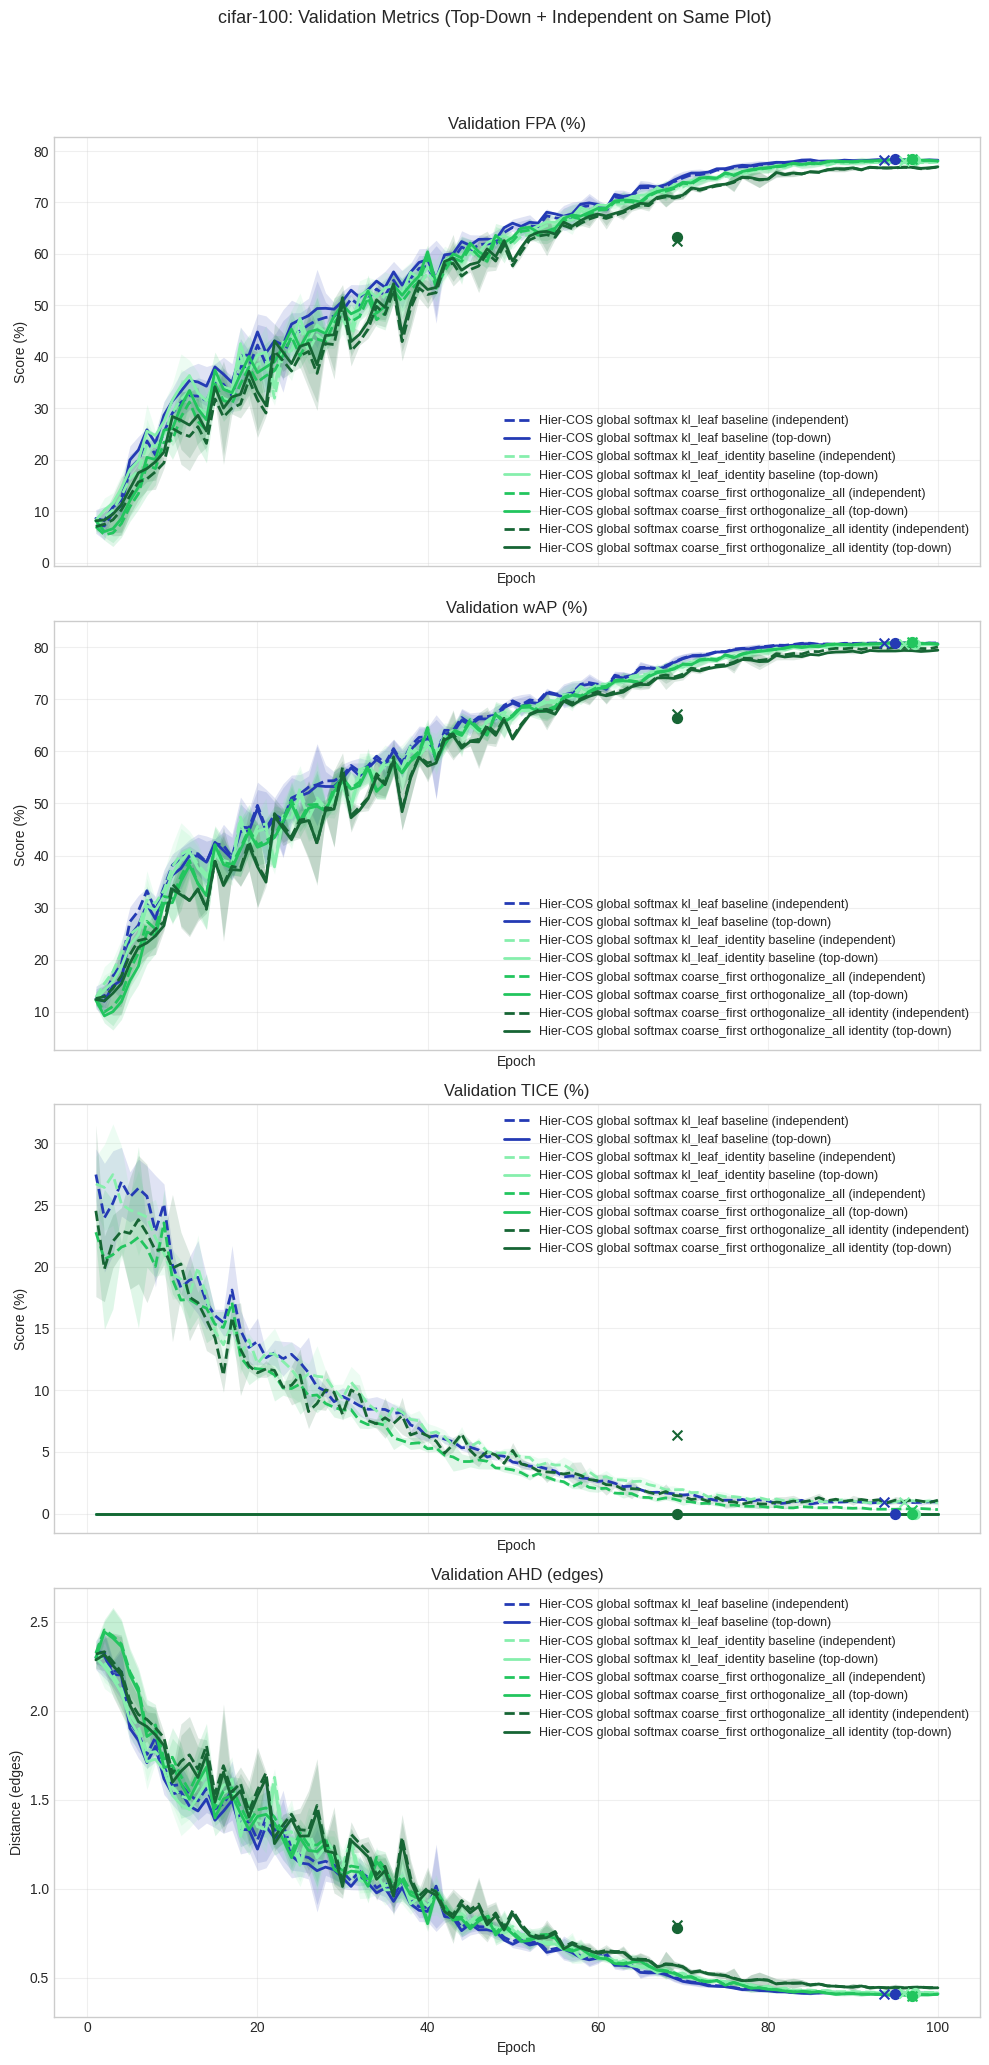

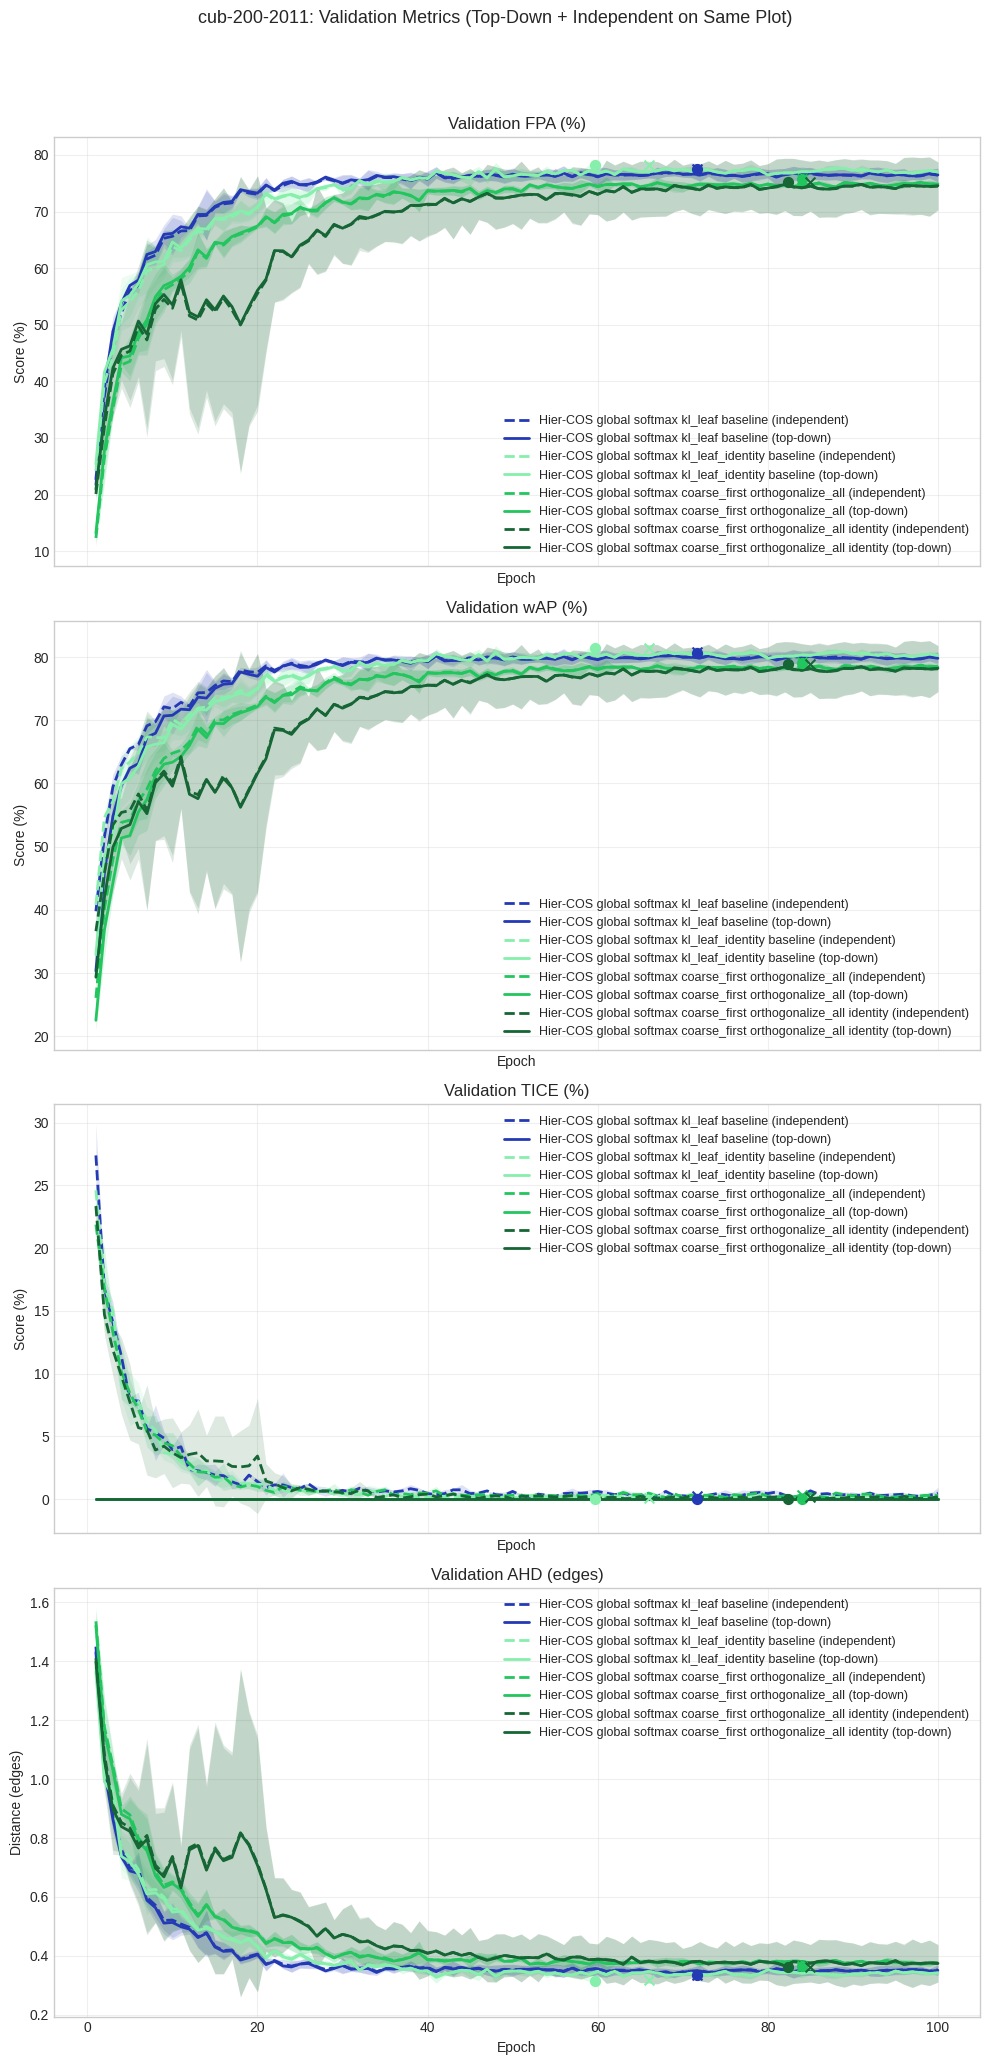

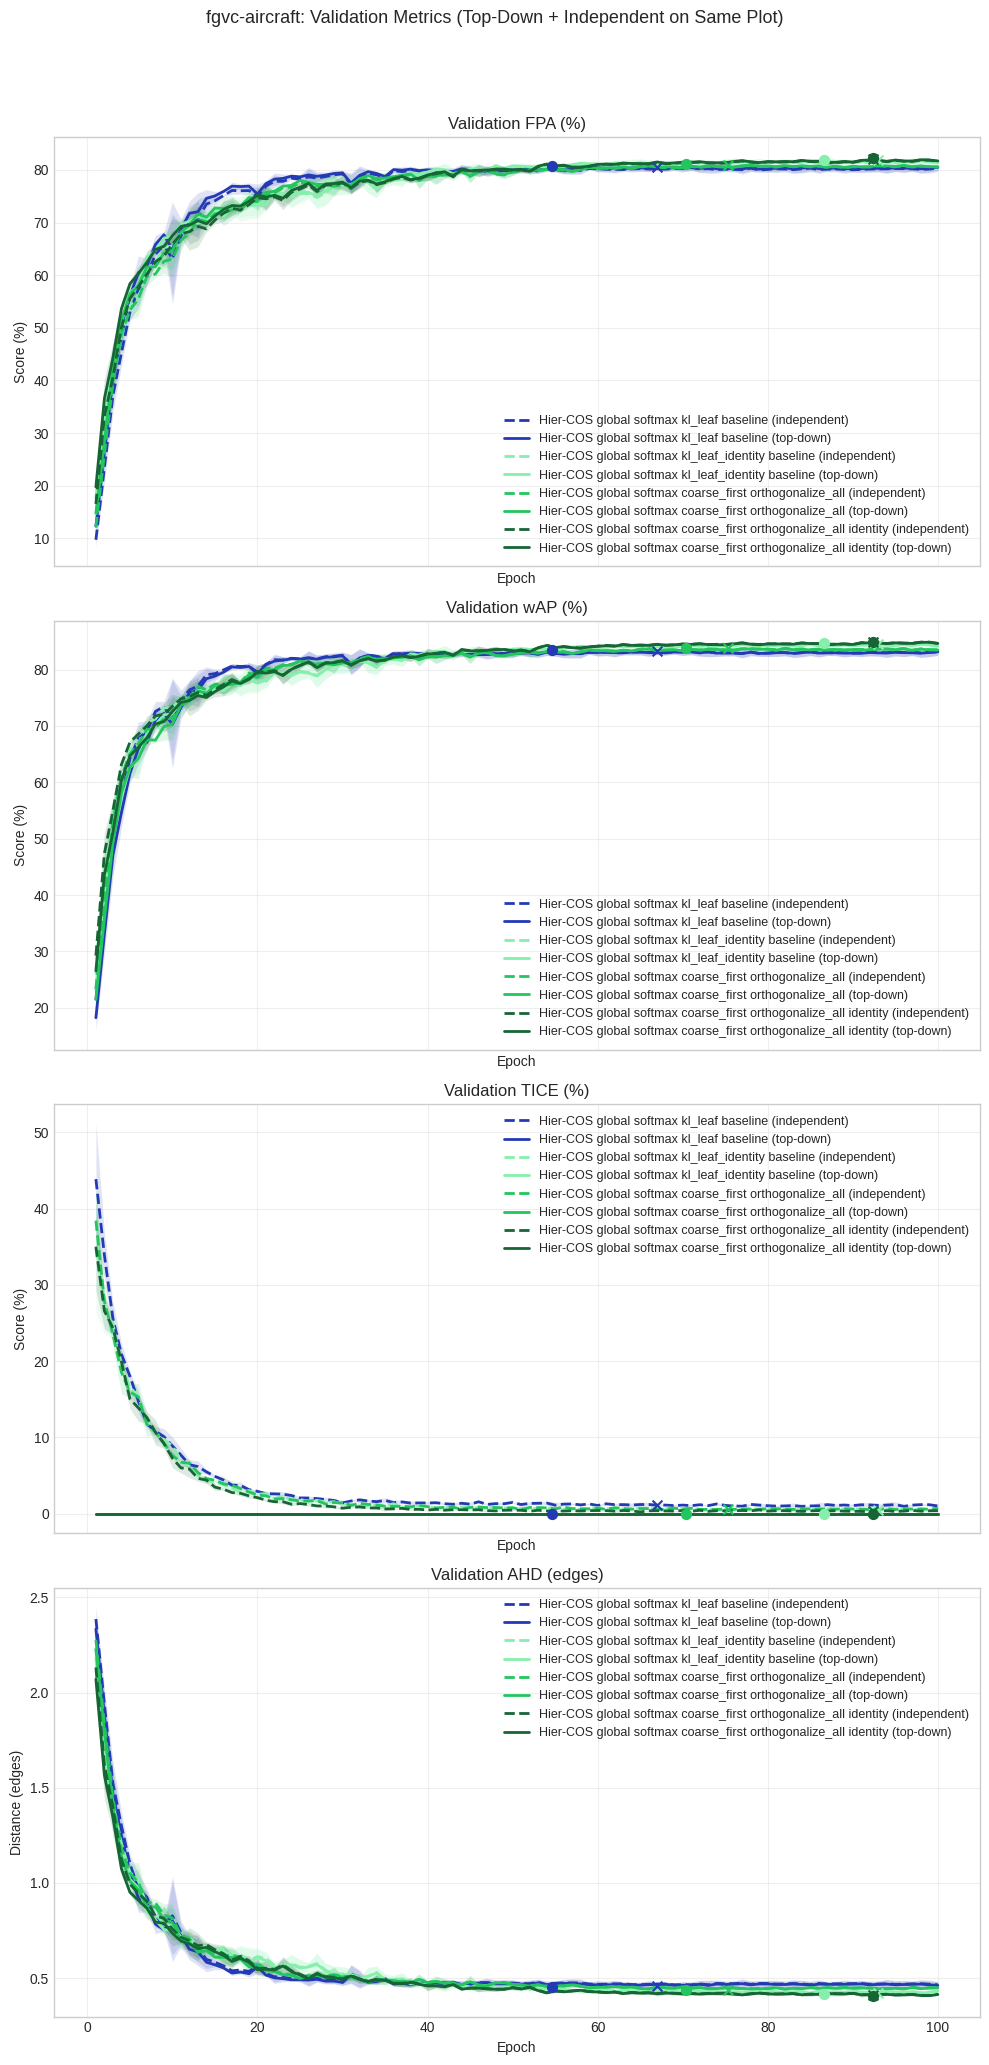

In [14]:
analysis.plot_validation_curves()


Interpretation note:
- For `FPA` and `wAP`, higher is better; for `TICE`, lower is better.
- Compare solid vs dashed lines of the same color to isolate hierarchy-enforcement effects for one run.
- Compare colors at the same line style to compare runs under the same decoding mode.

## Projection Diagnostics (If Available)

This section visualizes projection diagnostics logged in `val_metrics` and `train_metrics` (when available):
- `proj_constraint_alpha`, `proj_constraint_strength`, `proj_temperature`, `proj_mode_intrinsic_soft`

For standard Hier-COS runs these keys may be absent; in that case the section prints a per-dataset skip message.


In [15]:
analysis.plot_projection_diagnostics()


[cifar-100] No projection diagnostics found in selected runs.
[cub-200-2011] No projection diagnostics found in selected runs.
[fgvc-aircraft] No projection diagnostics found in selected runs.


## Training Loss Comparison

This section compares aggregate losses (`total`, `ce`, `reg`, and exact `kl` for `kl_reg`) and exact weighted per-level objectives (`loss_level_*`, when available).


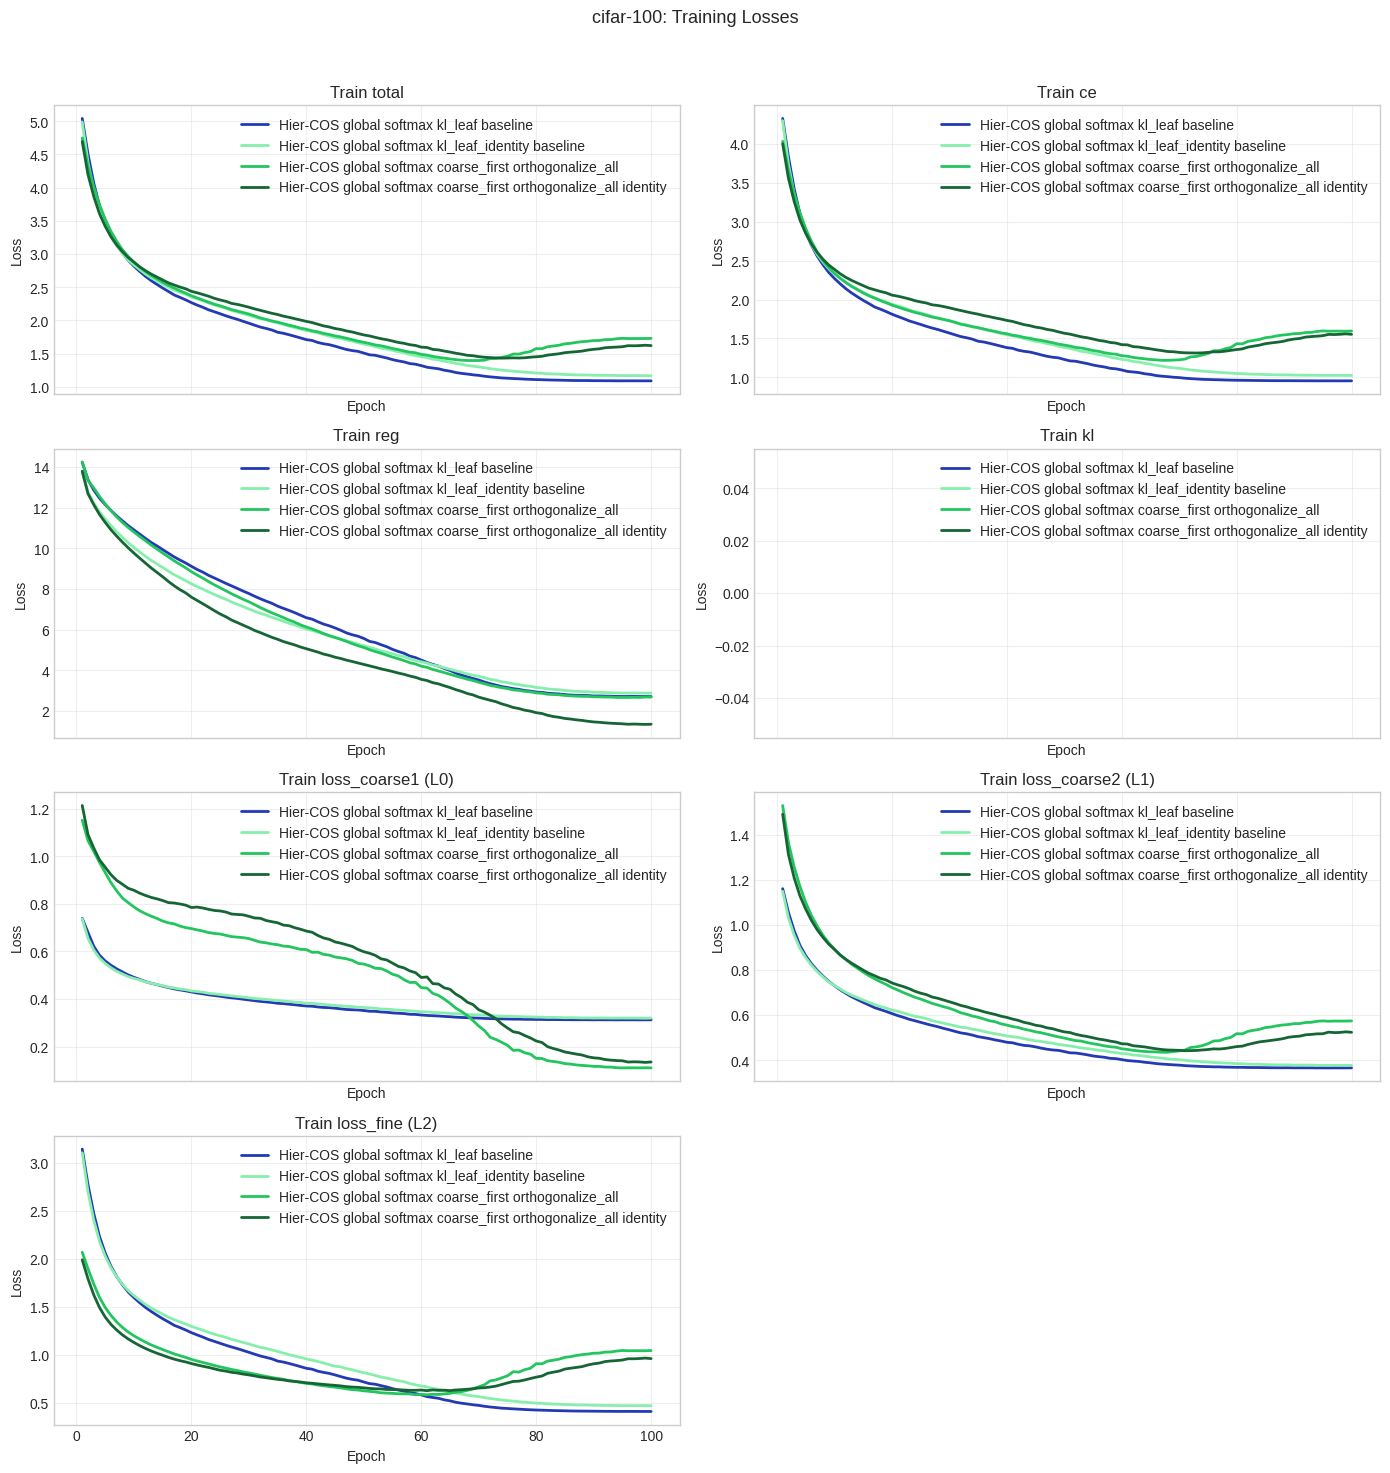

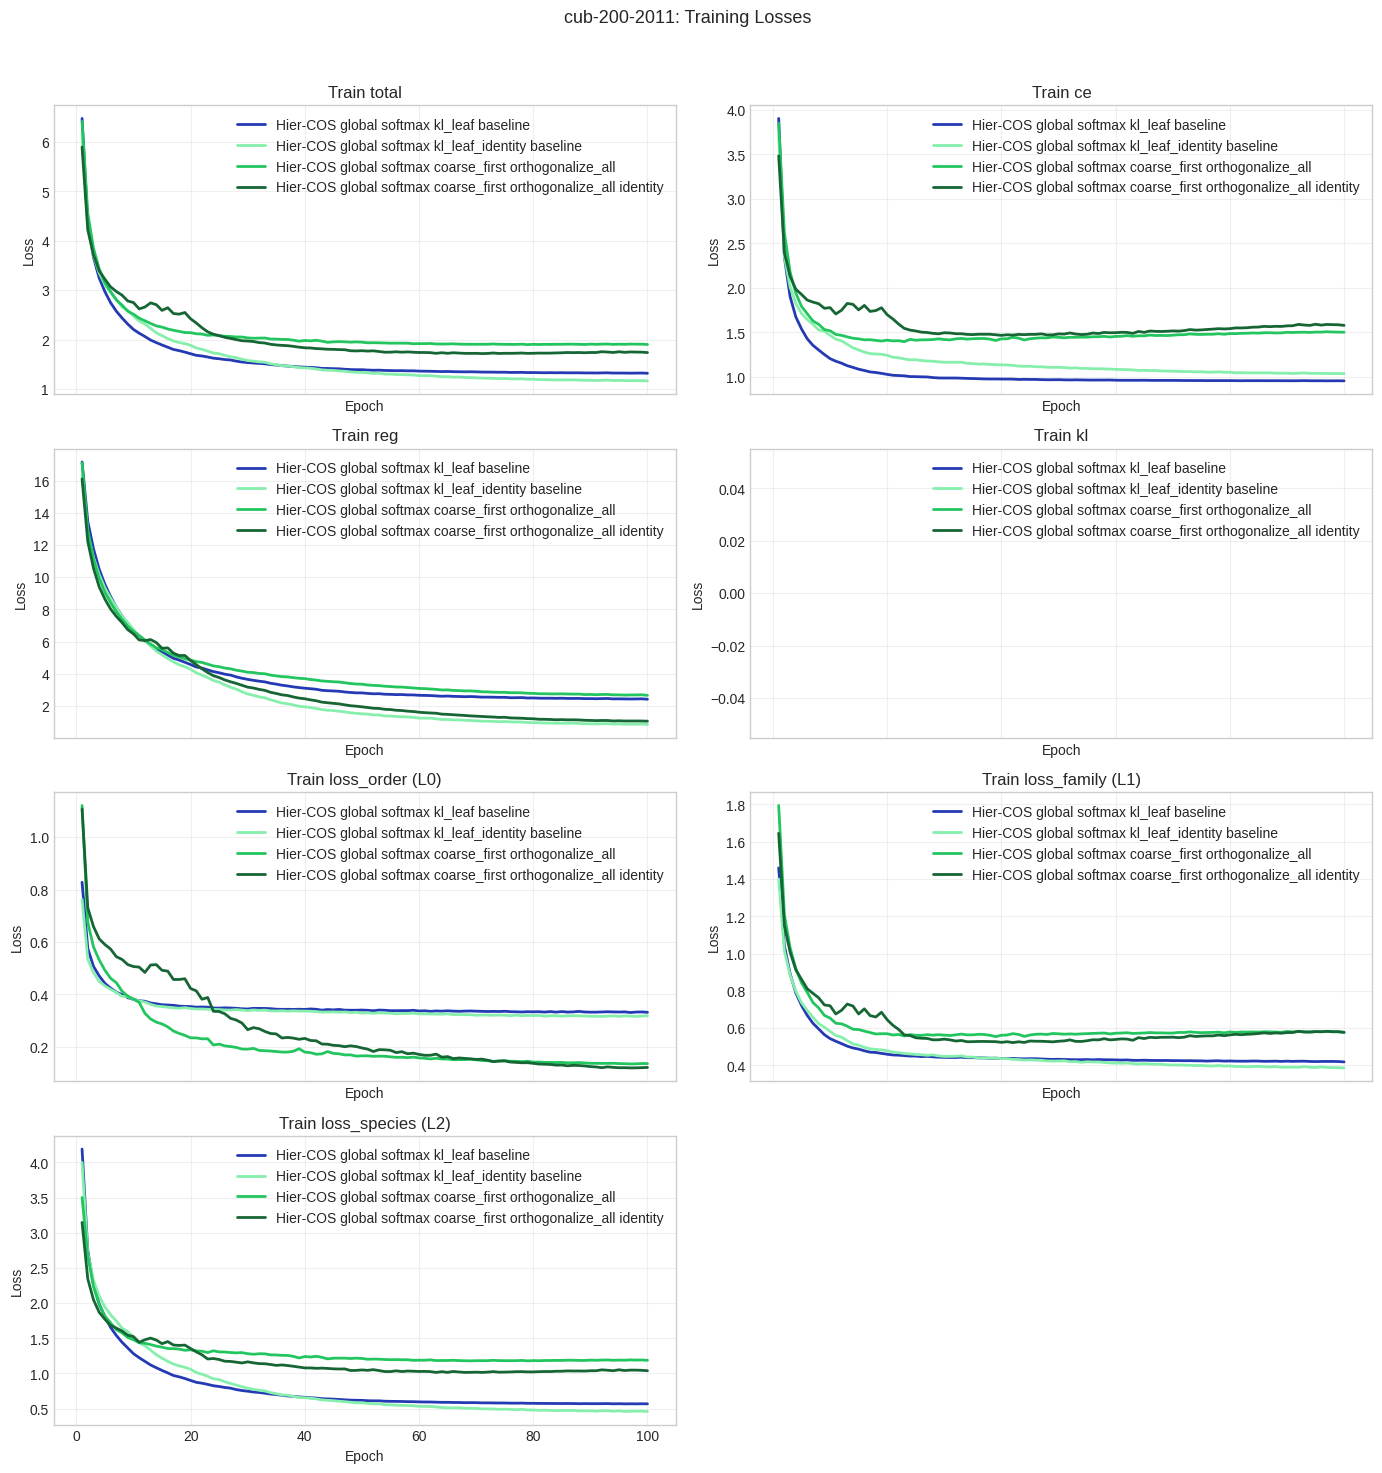

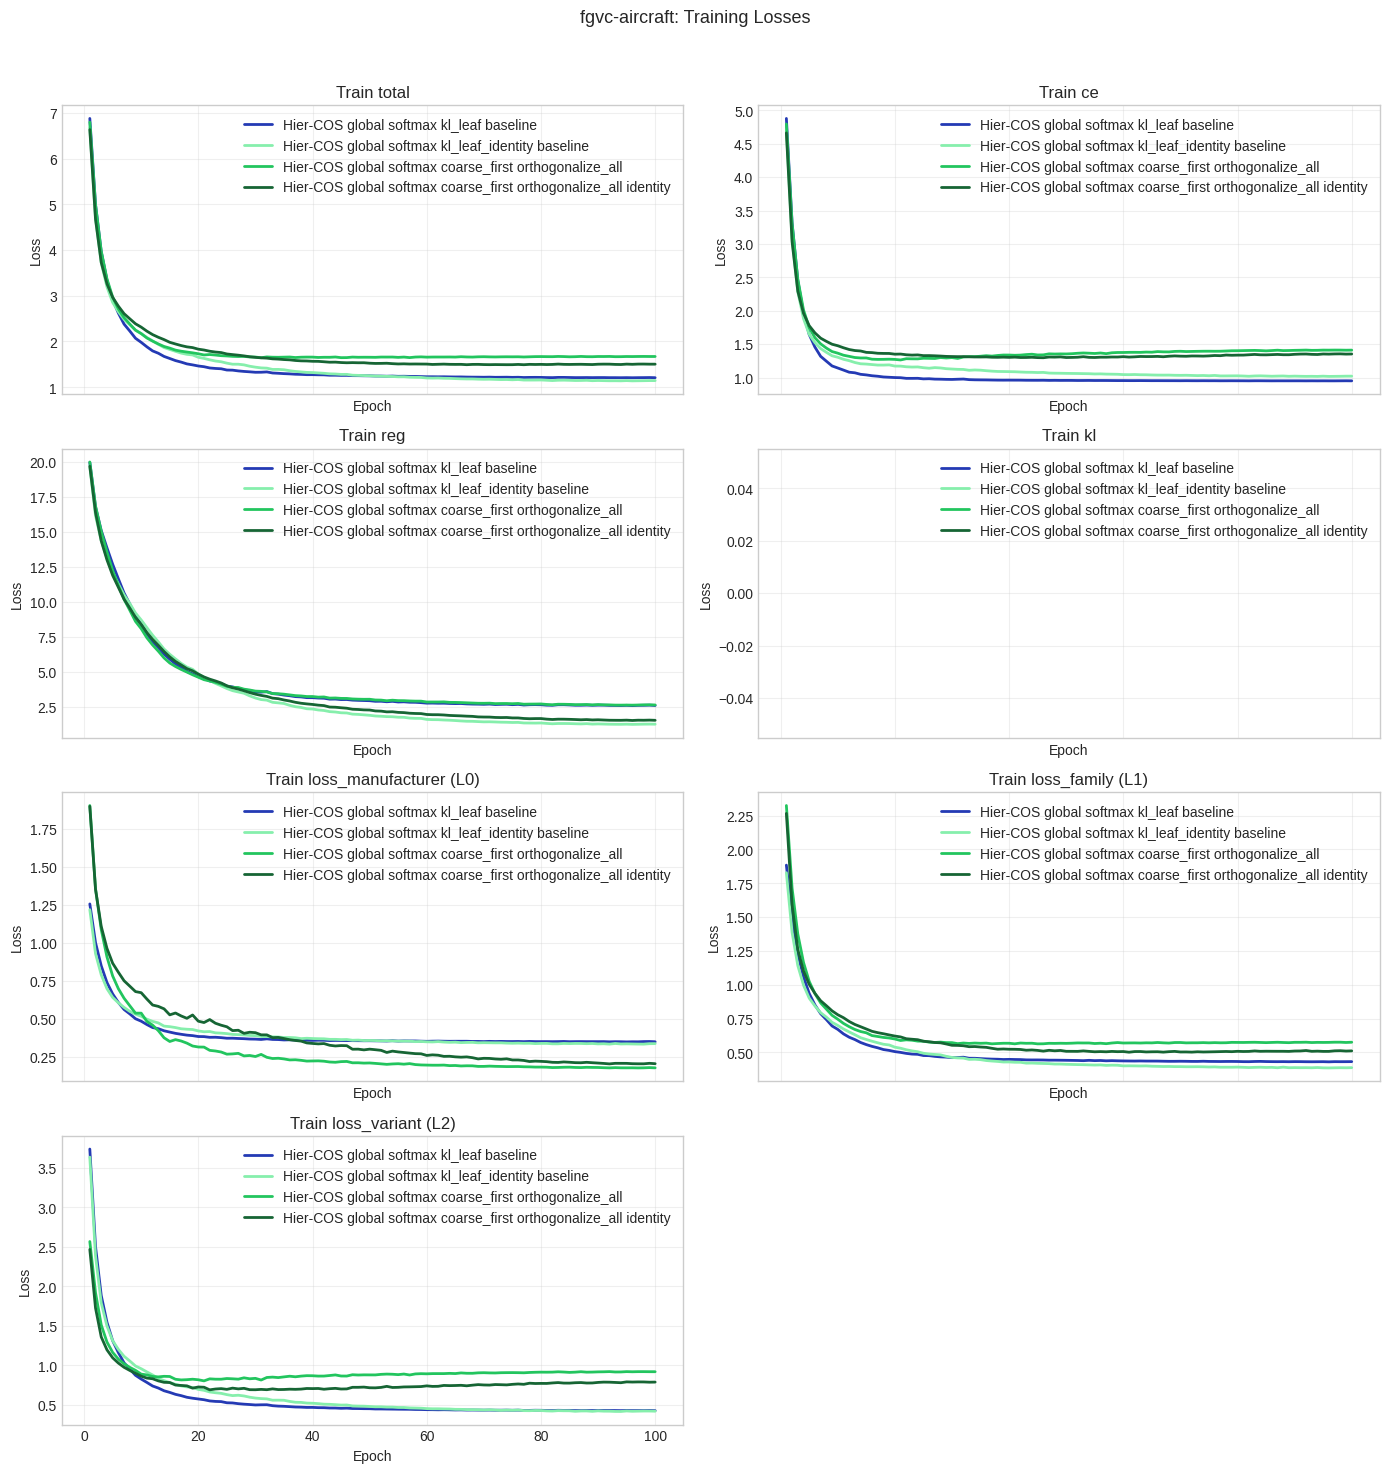

In [16]:
analysis.plot_training_losses(aggregate_loss_keys=['total', 'ce', 'reg', 'kl'])


Interpretation note:
- Lower is better for all loss curves.
- Compare `total` first for optimization behavior, then `loss_level_*` to see where depth-specific training differs.
- If one run has consistently lower shallow-level loss but much higher deep-level loss, expect weaker fine-grained accuracy and path metrics.

## Per-Run Per-Level Training Losses (Per Dataset)

Interpretation note:
- Each chart corresponds to one selected run in its dataset section.
- Lines in the same chart are all available `loss_level_*` training losses (lower is better).



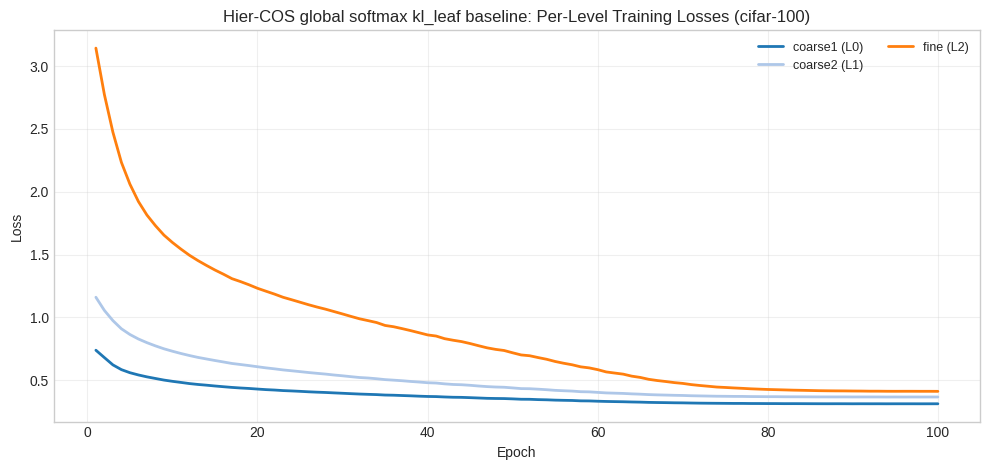

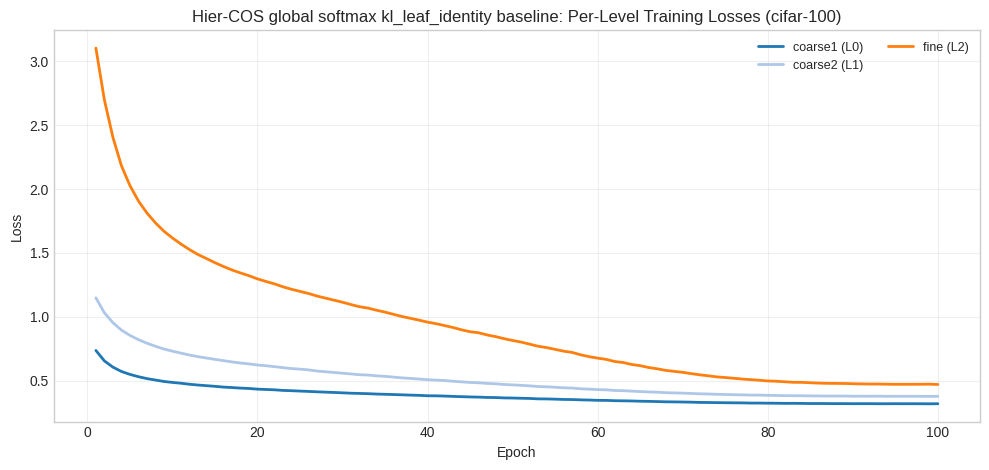

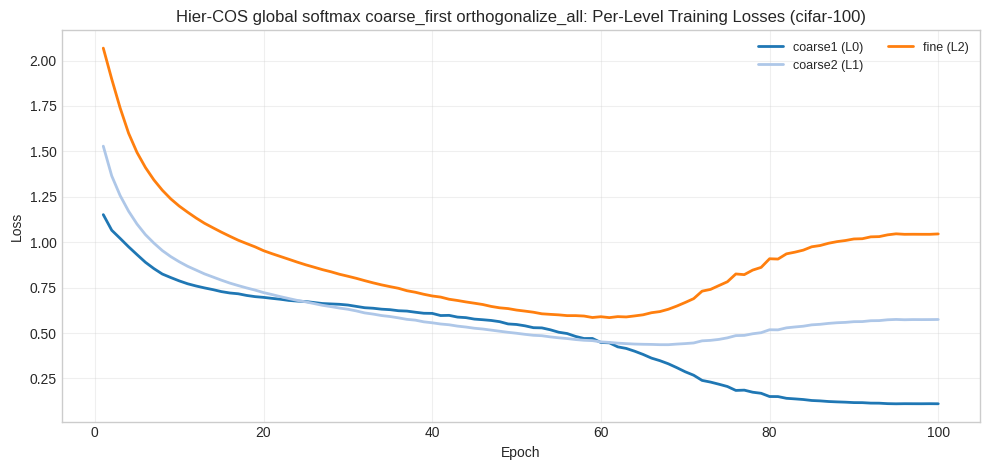

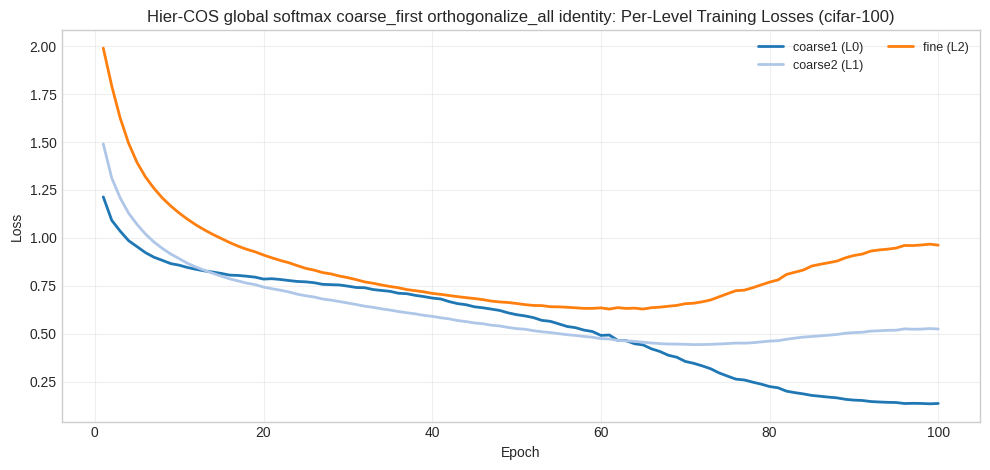

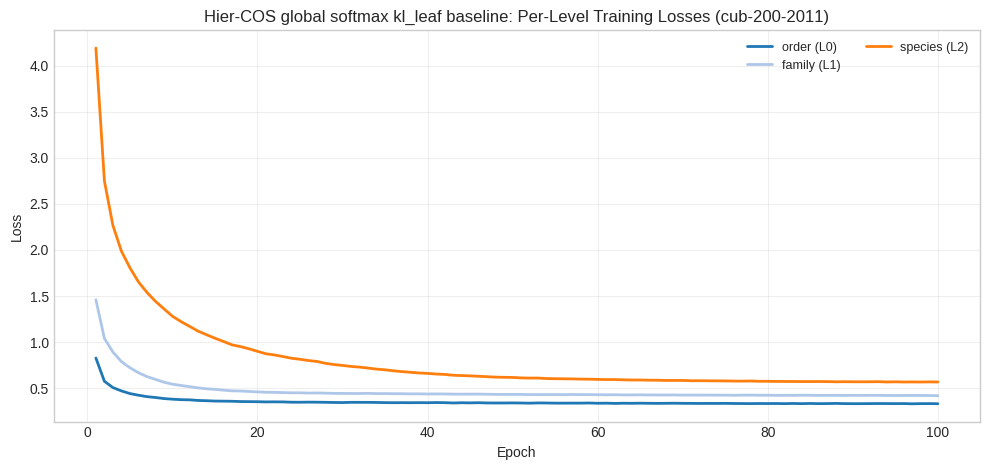

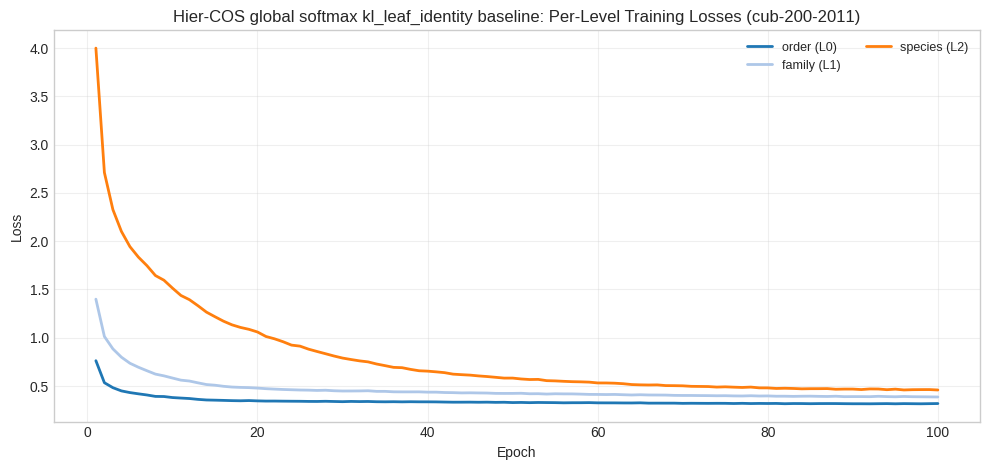

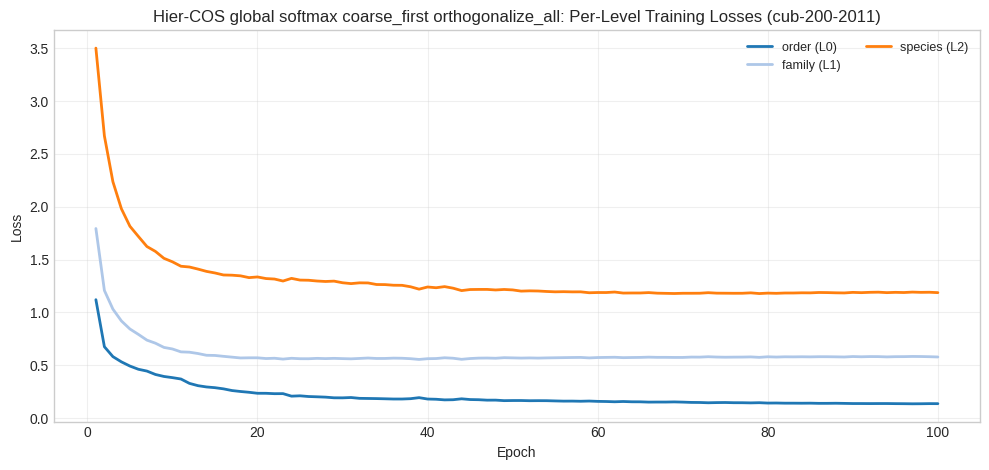

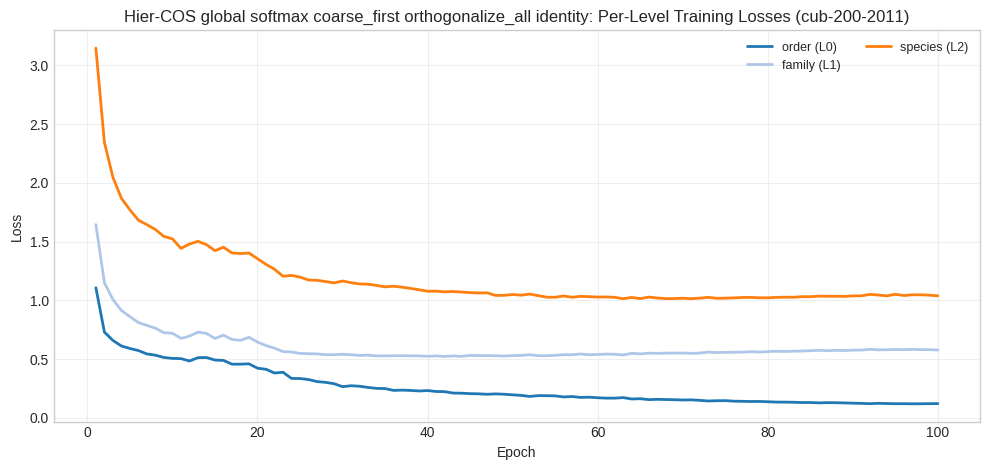

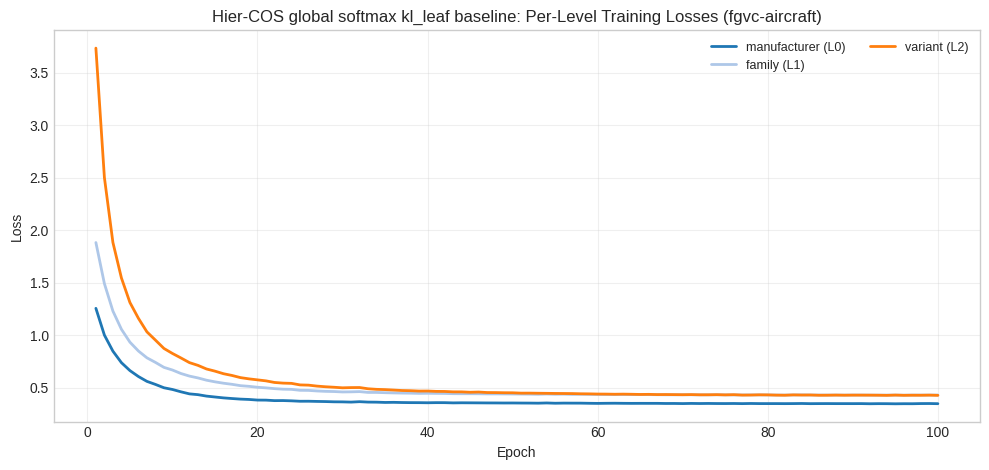

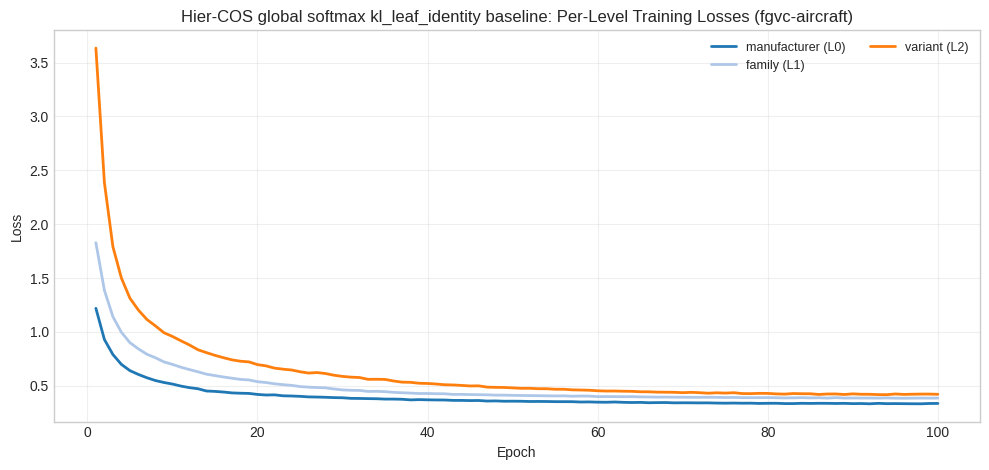

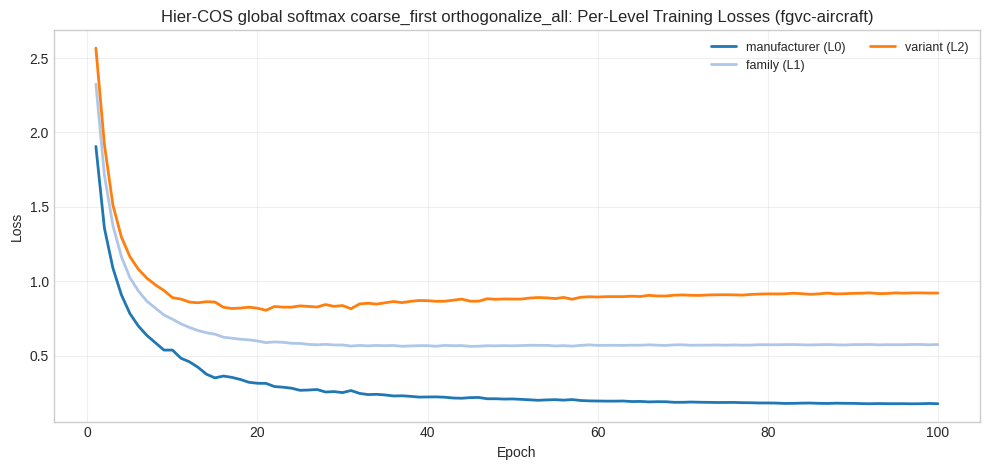

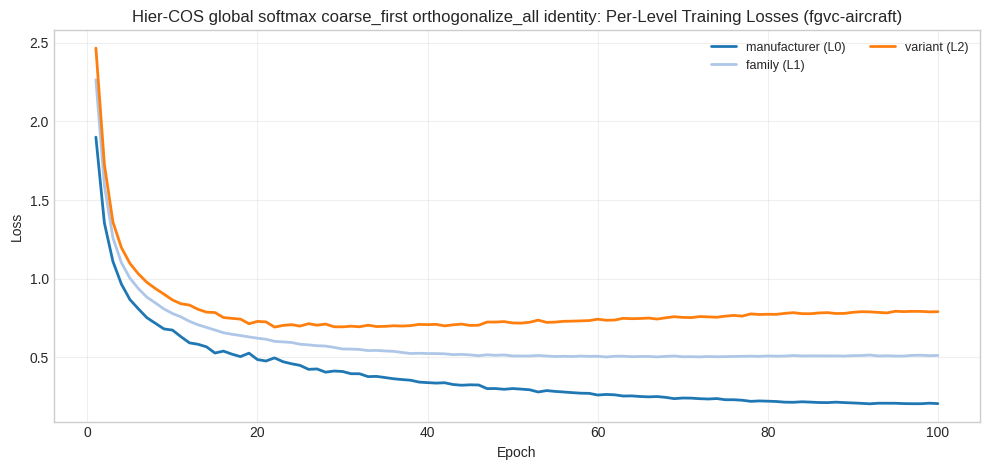

In [17]:
analysis.plot_per_run_per_level_training_losses()


## Gradient Diagnostics (Train)

This section visualizes trunk-based gradient/parameter metrics and optional projection diagnostics stored in `train_metrics` for each epoch.

For Hier-COS, many of these metrics are available only in CE/diagnostic-focused runs. If unavailable, corresponding plots are skipped automatically.


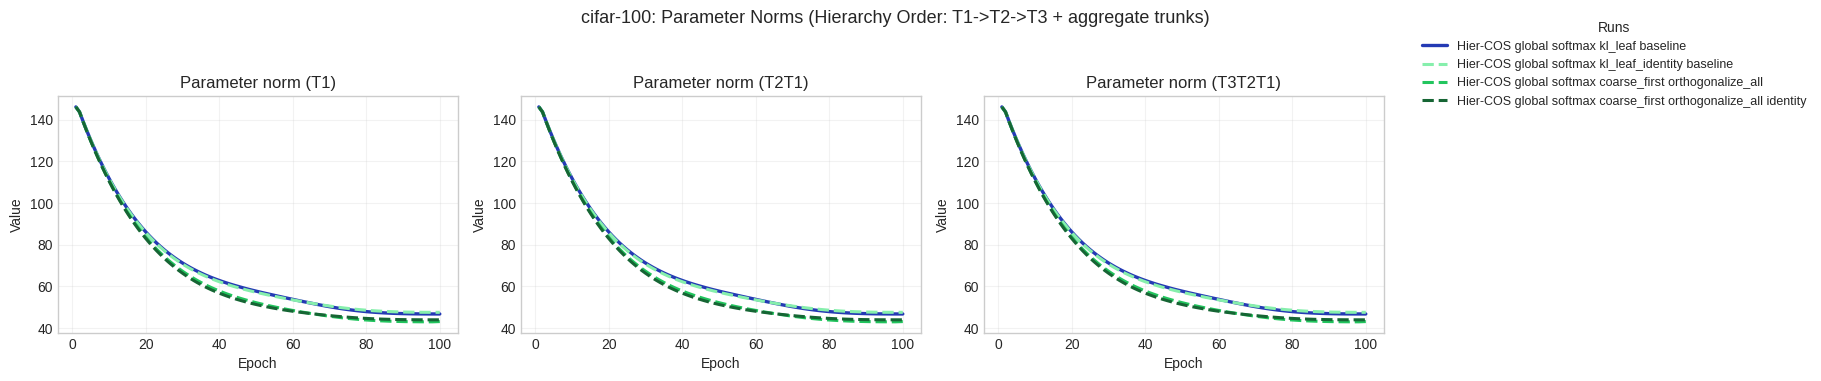

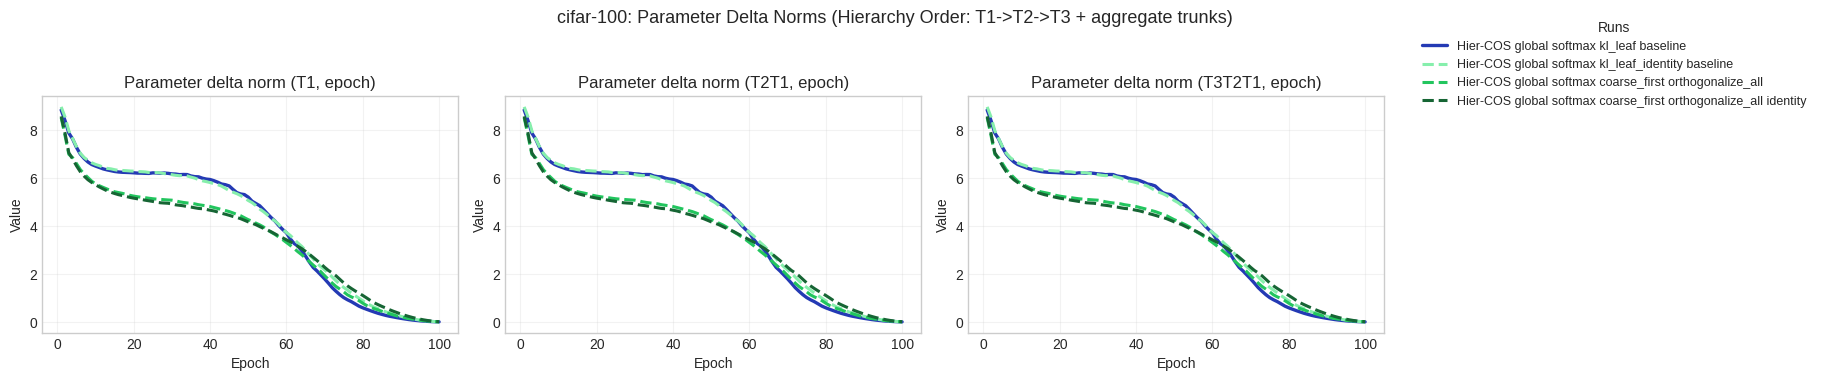

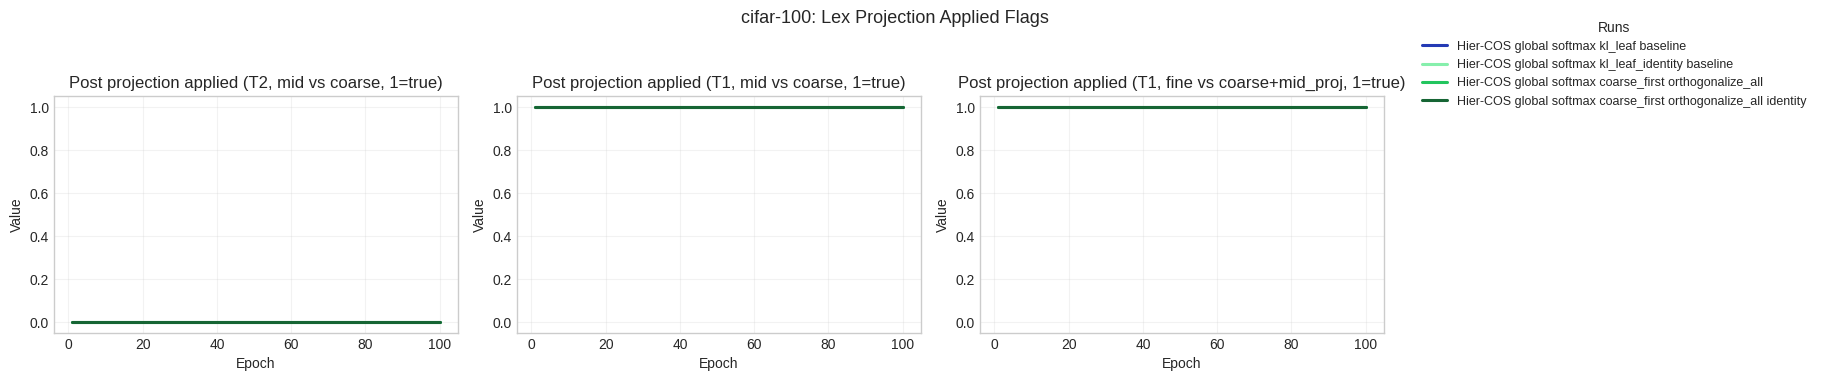

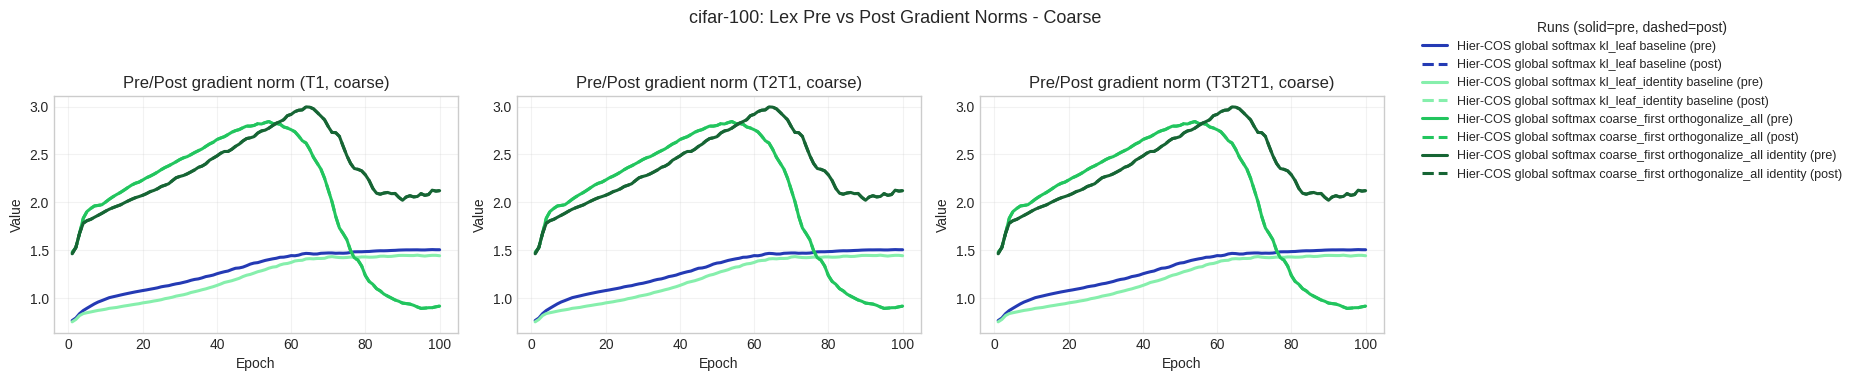

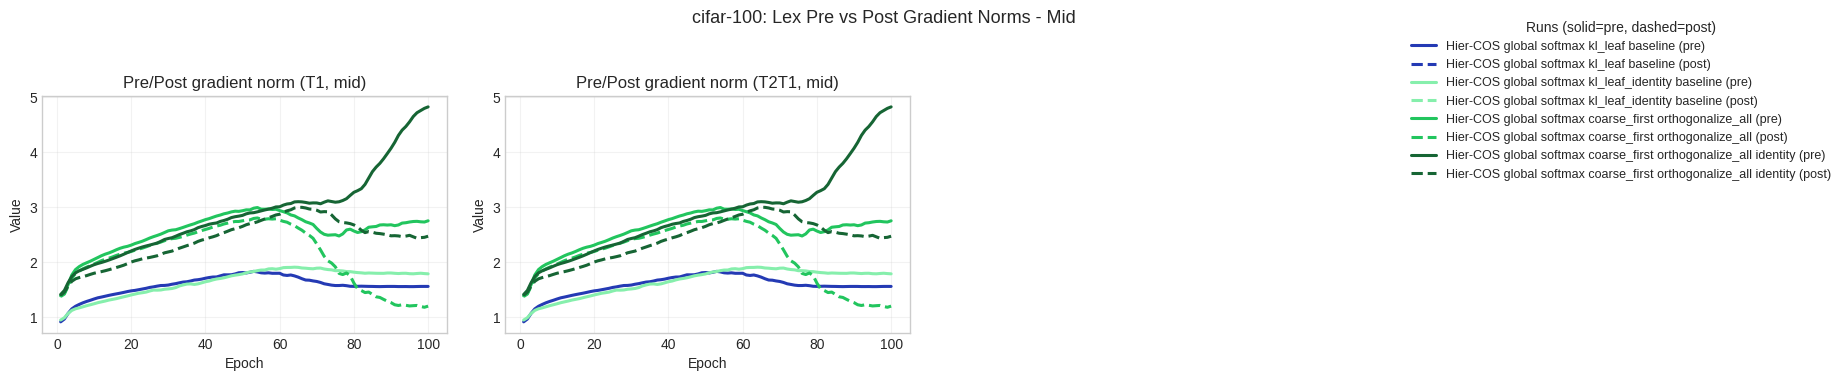

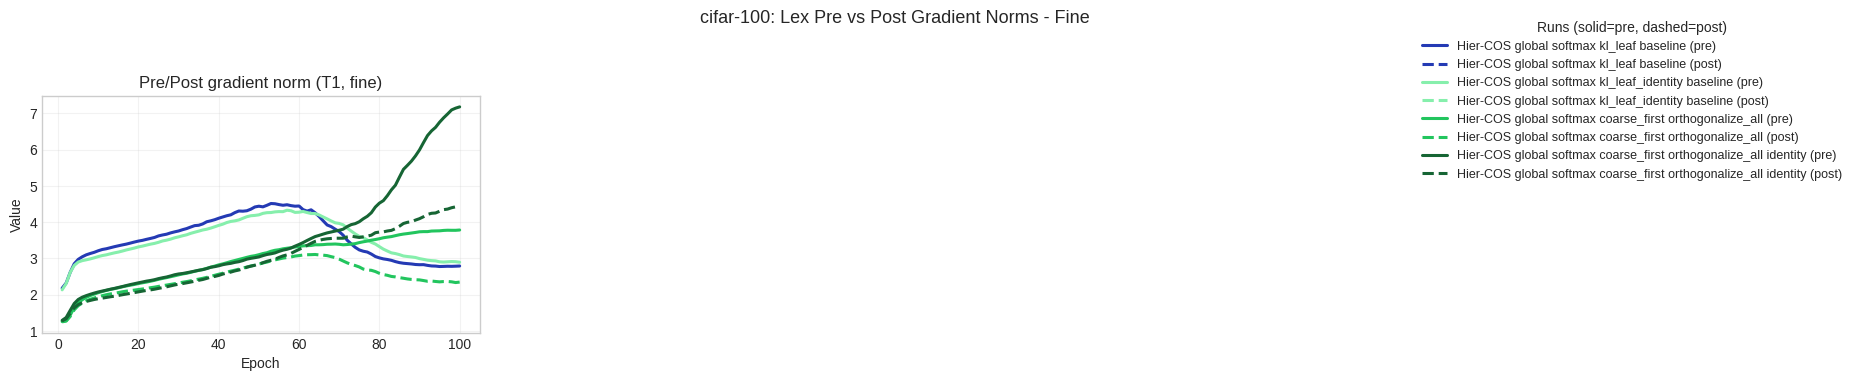

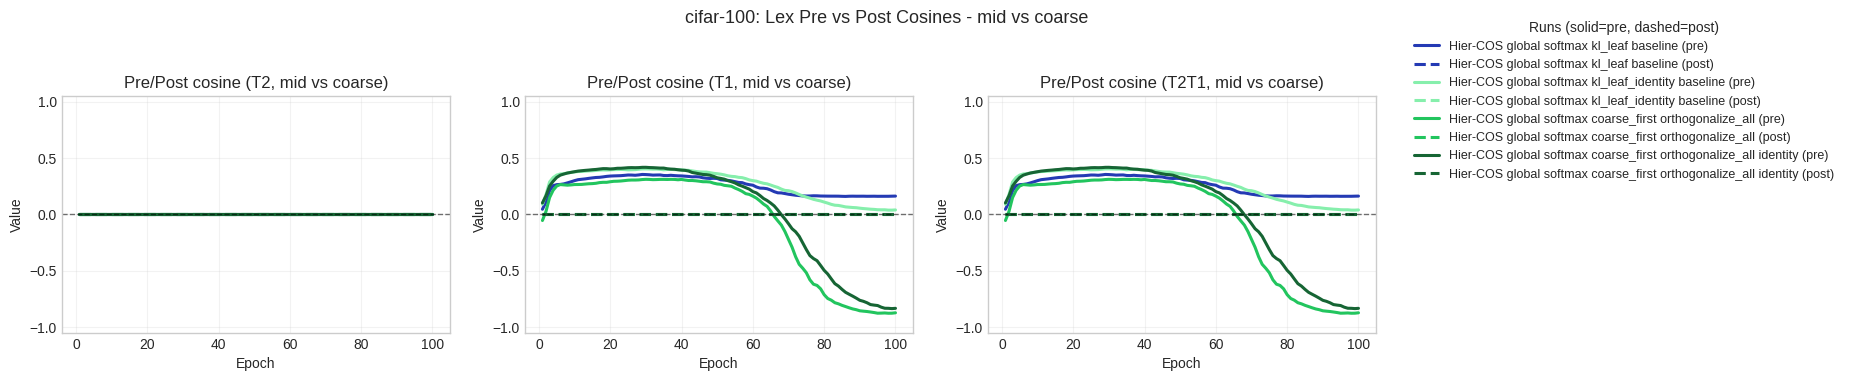

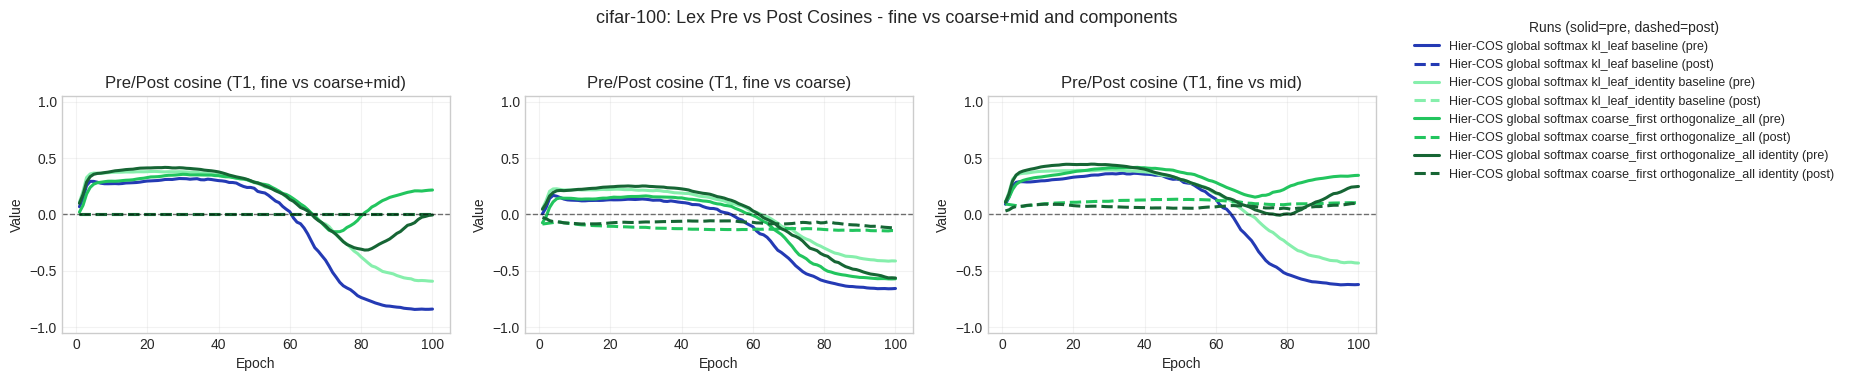

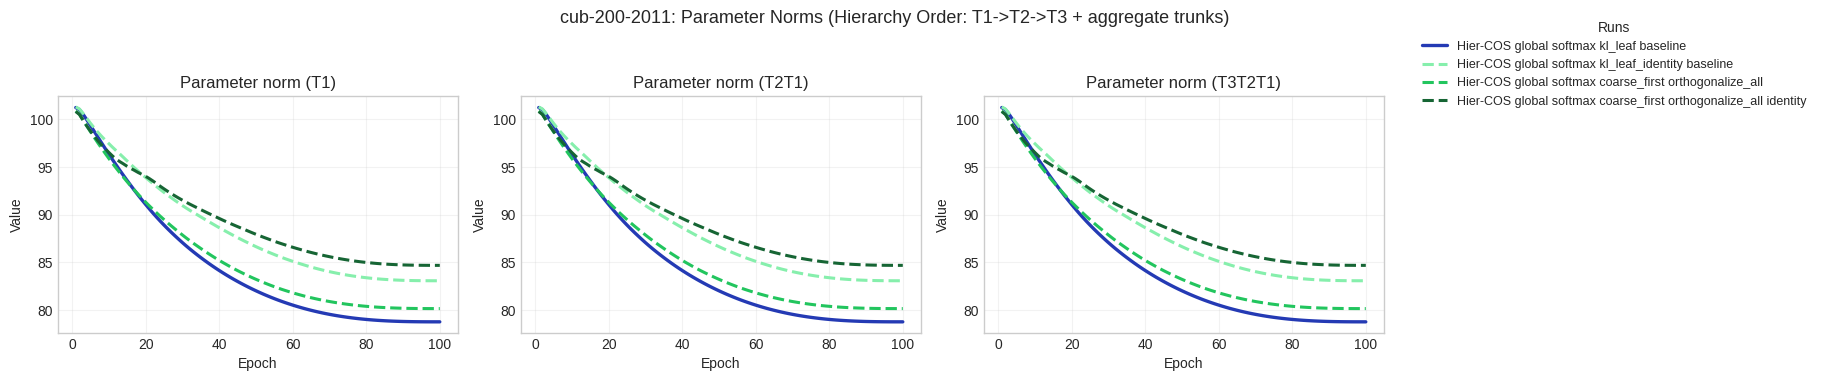

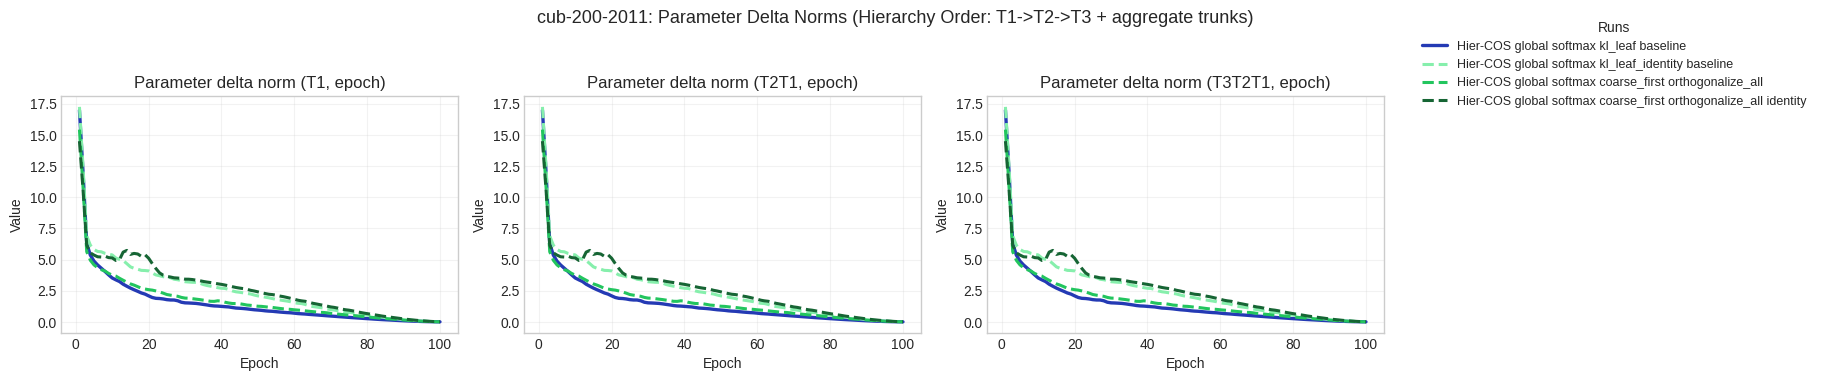

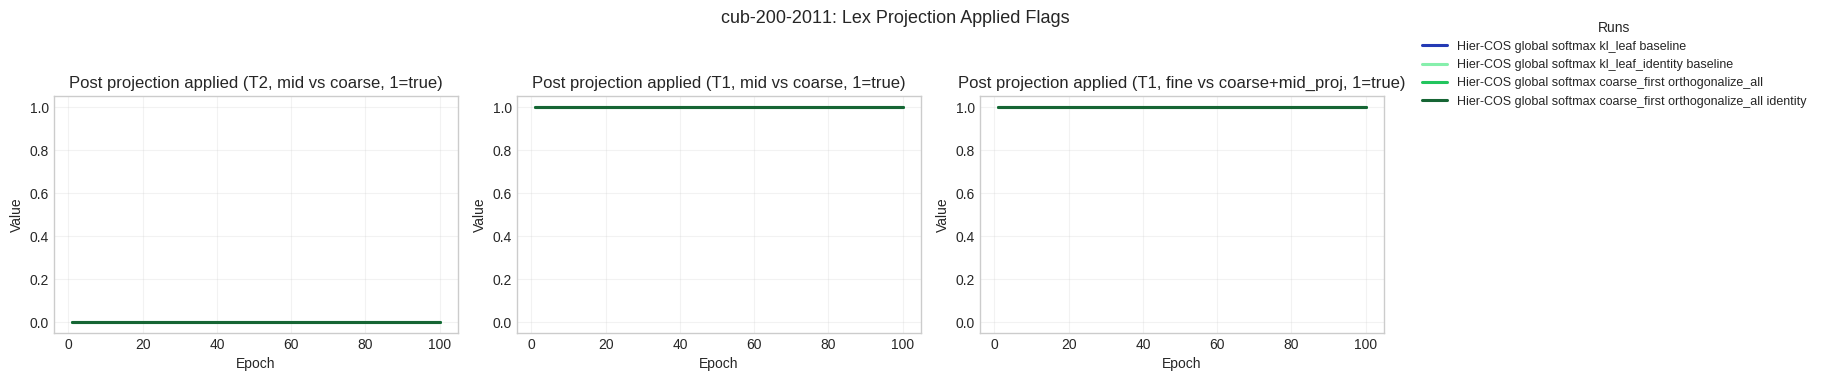

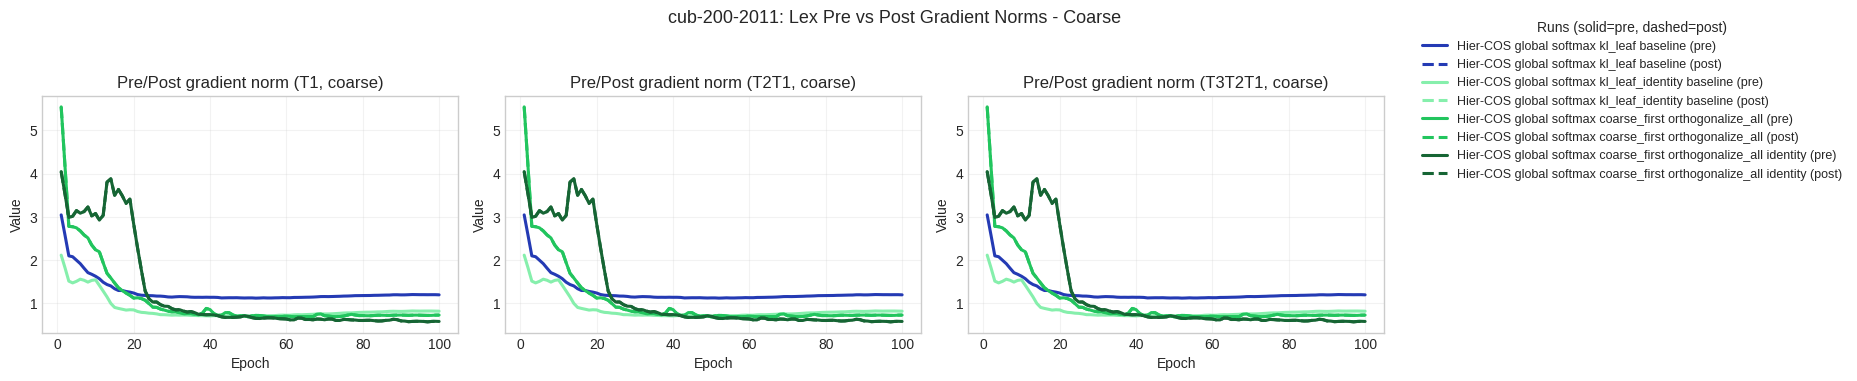

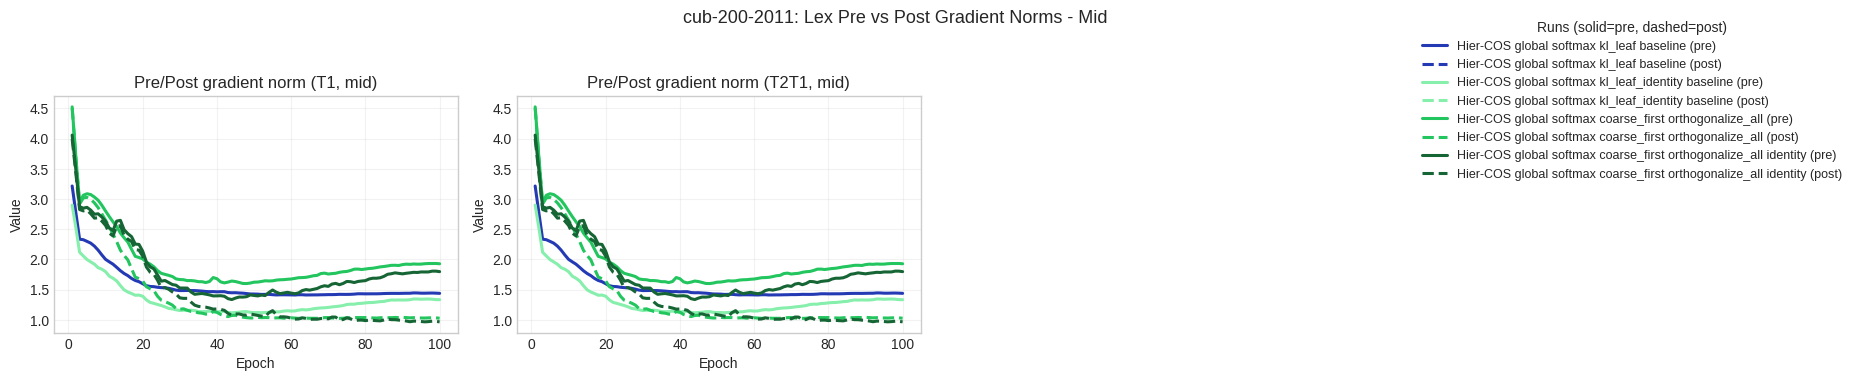

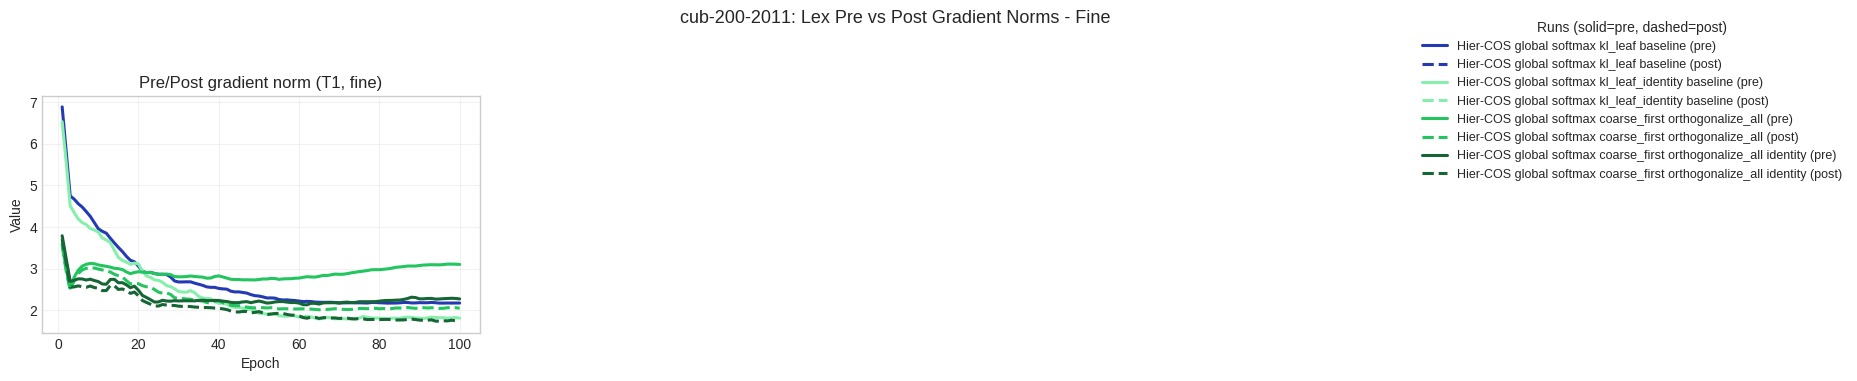

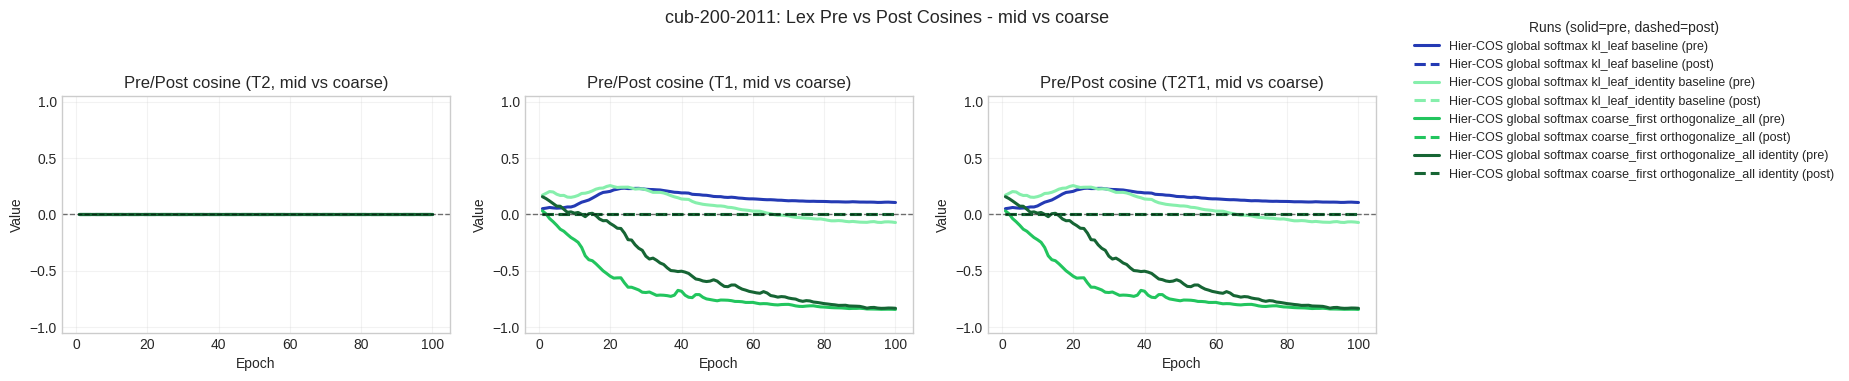

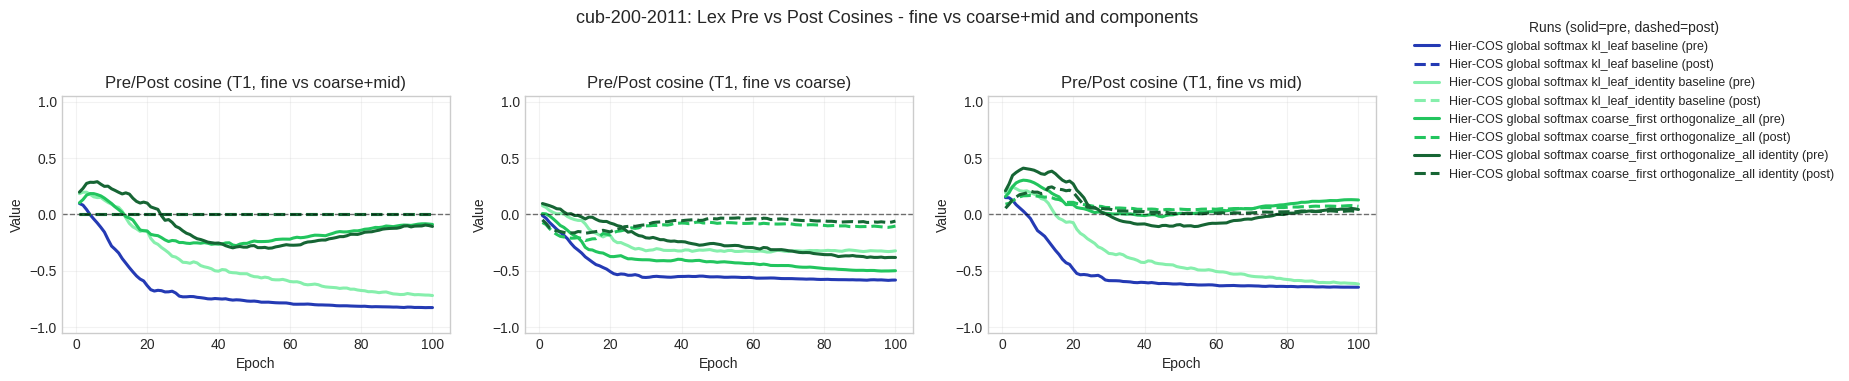

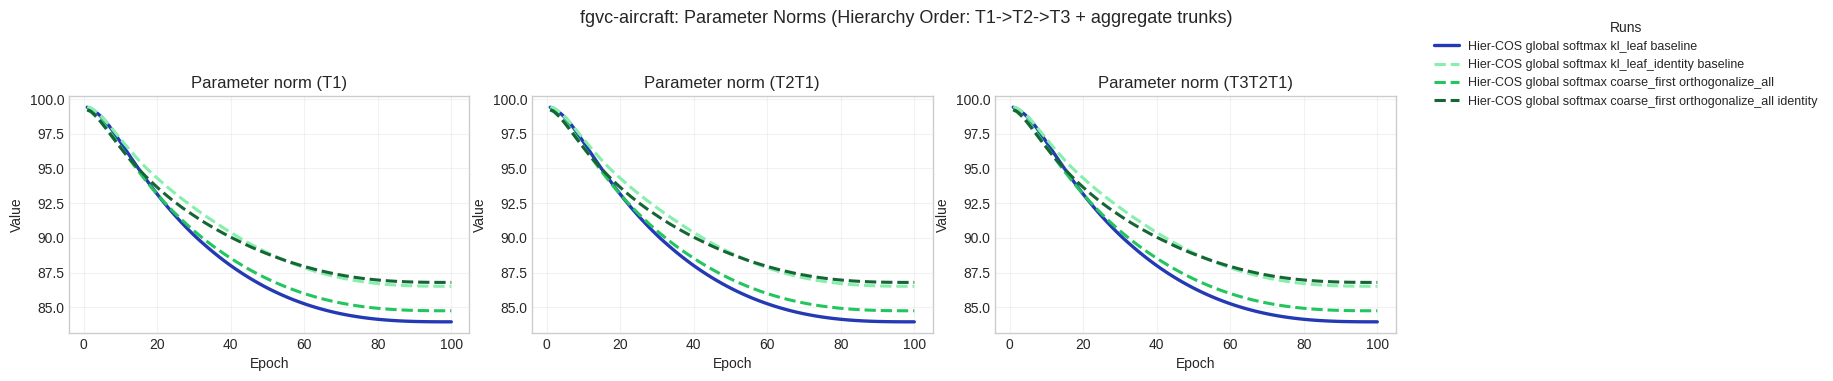

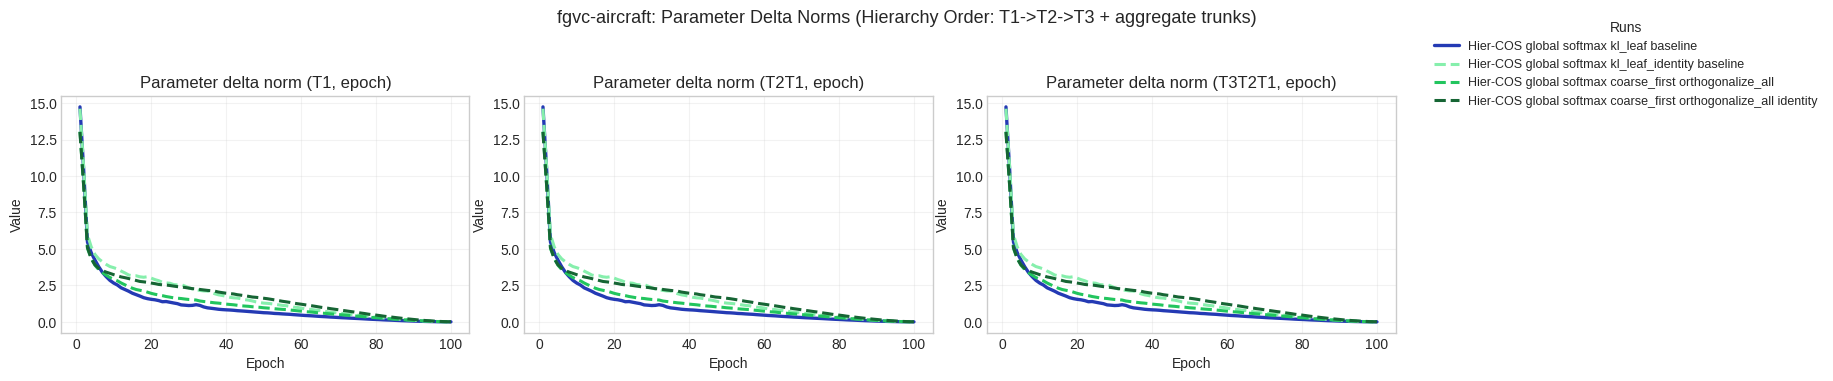

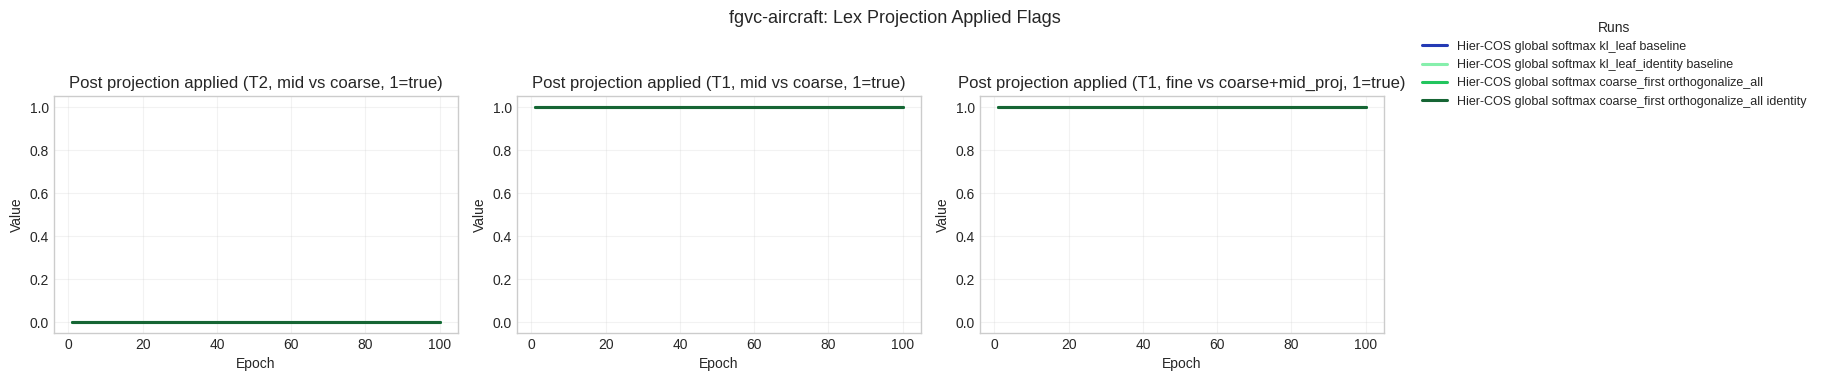

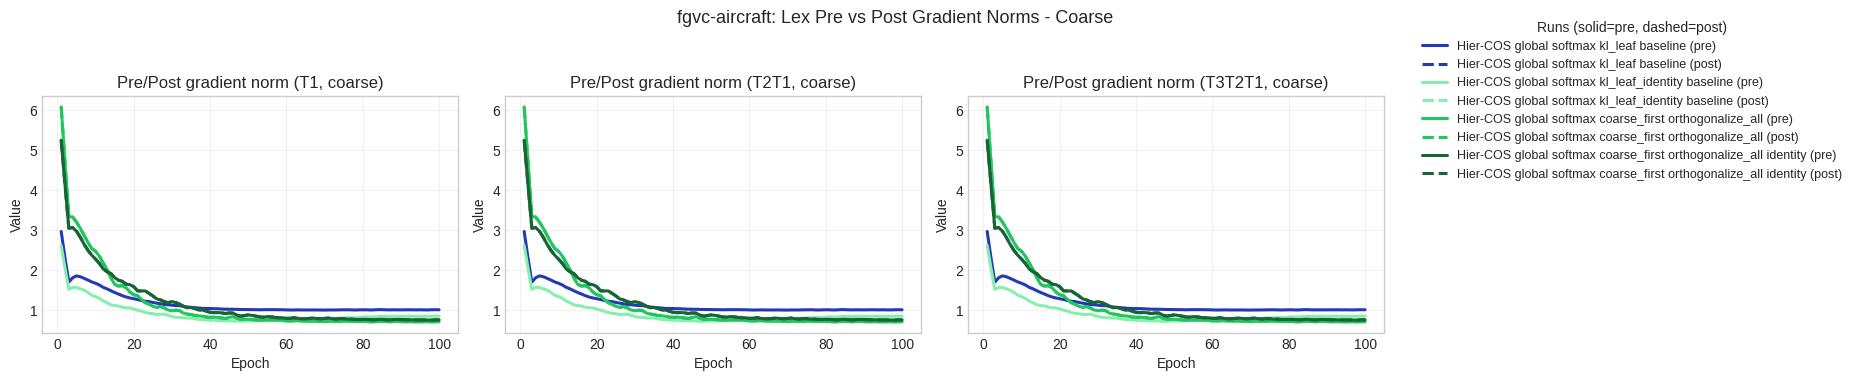

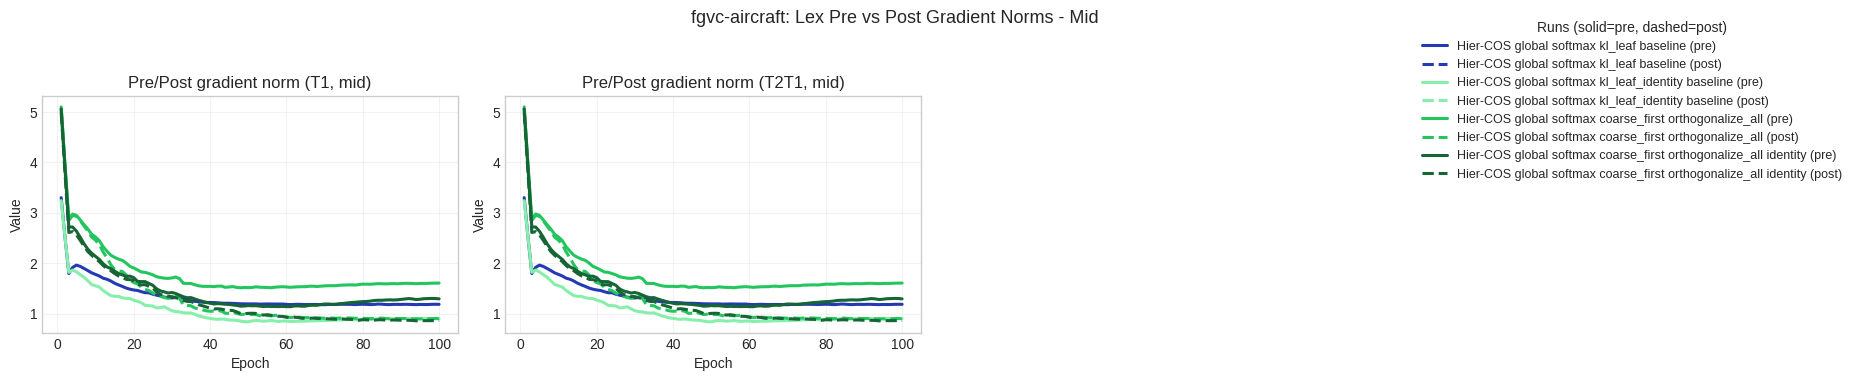

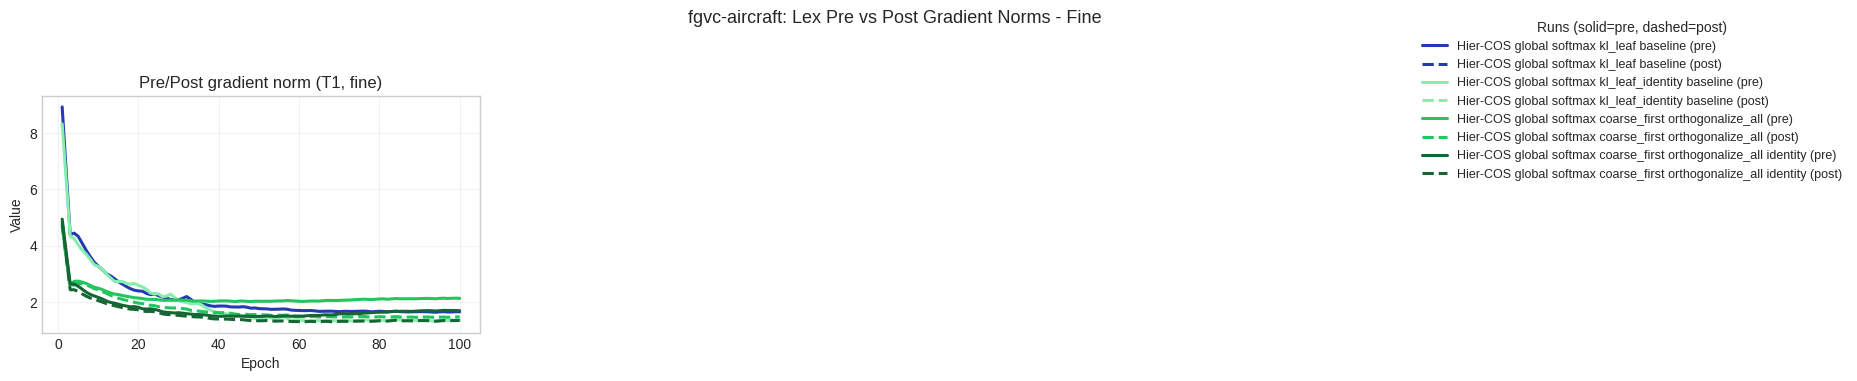

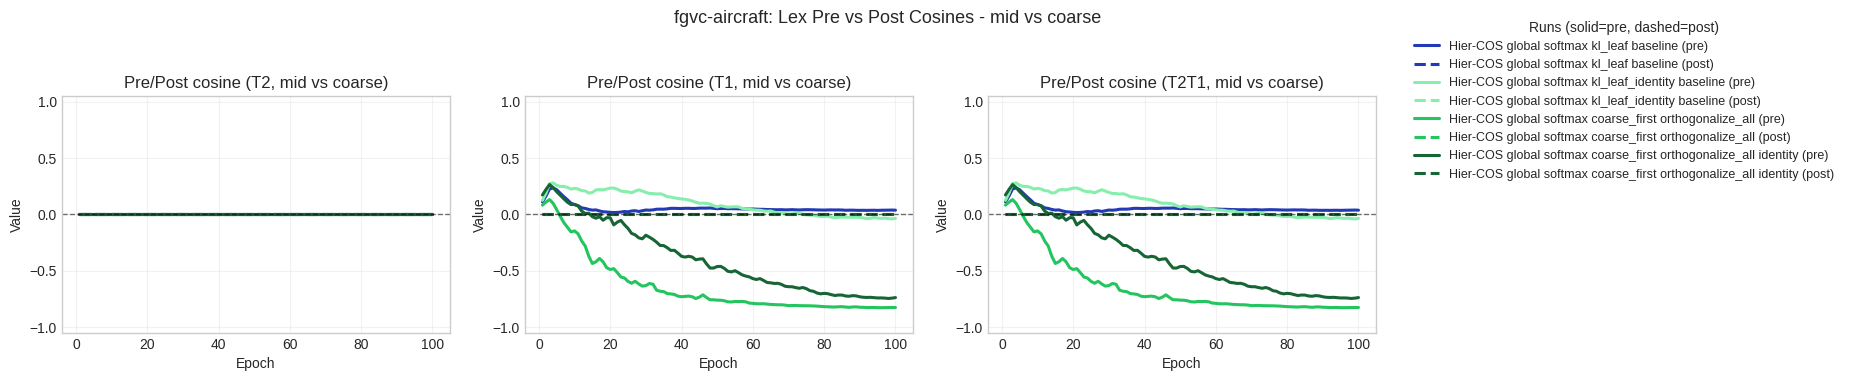

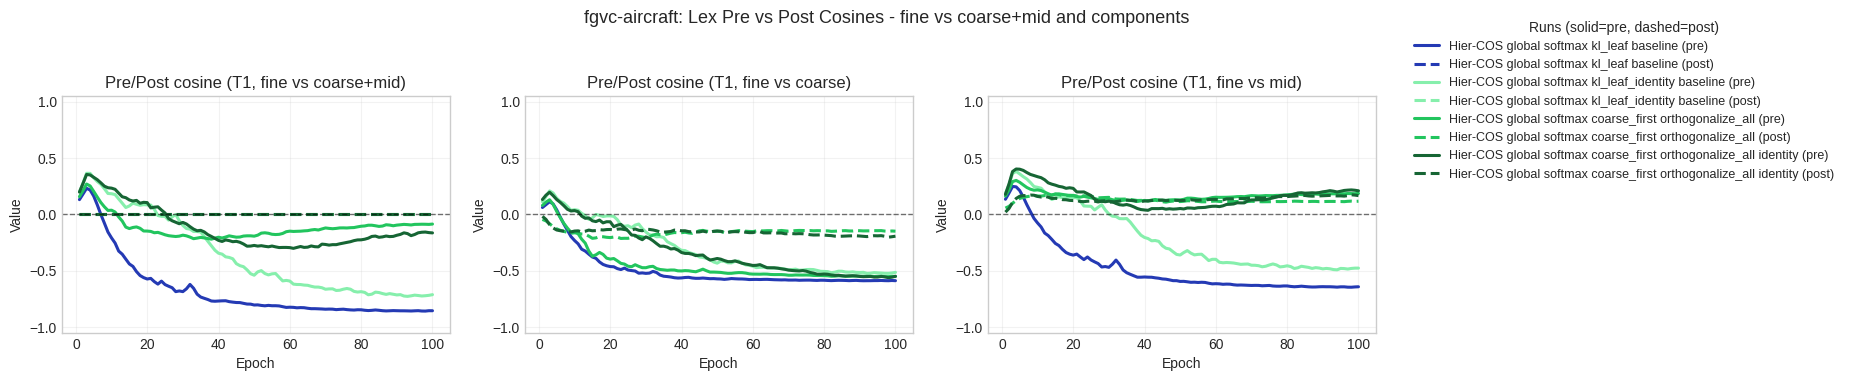

In [18]:
GRAD_SMOOTH_WINDOW = 2
SHOW_RAW_OVERLAY = False
RAW_ALPHA = 0.12
N_COLS = 3
LOG_SCALE_FOR_NORMS = False
AX_WIDTH = 6.0
AX_HEIGHT = 3.8
LEGEND_GUTTER_RATIO = 0.78
LEGEND_MAX_ROWS_PER_COL = 10

analysis.plot_gradient_diagnostics(
    smooth_window=GRAD_SMOOTH_WINDOW,
    show_raw_overlay=SHOW_RAW_OVERLAY,
    raw_alpha=RAW_ALPHA,
    n_cols=N_COLS,
    log_scale_for_norms=LOG_SCALE_FOR_NORMS,
    ax_width=AX_WIDTH,
    ax_height=AX_HEIGHT,
    legend_gutter_ratio=LEGEND_GUTTER_RATIO,
    legend_max_rows_per_col=LEGEND_MAX_ROWS_PER_COL,
)


Interpretation note:

- Large spikes in gradient norms indicate unstable update pressure for that subset/level path.
- If `grad_norm_t1_fine` collapses while `t1` coarse/mid stay high, fine supervision is not effectively reaching shared parameters.
- Negative cosine values indicate level conflict on the corresponding subset.
- `param_norm_*` is scale, `delta_param_norm_*` is per-epoch movement.
- In lex mode, projected cosines should move near 0 (orthogonality on the target mask).
- `post_projection_applied_* = 0` means the corresponding projection step was skipped for numerical safety.


## Per-Level Validation Accuracy (Top-Down and Independent)

Each level plot overlays both modes on the same axes:
- color = run
- line style = mode (`topdown` solid, `independent` dashed).

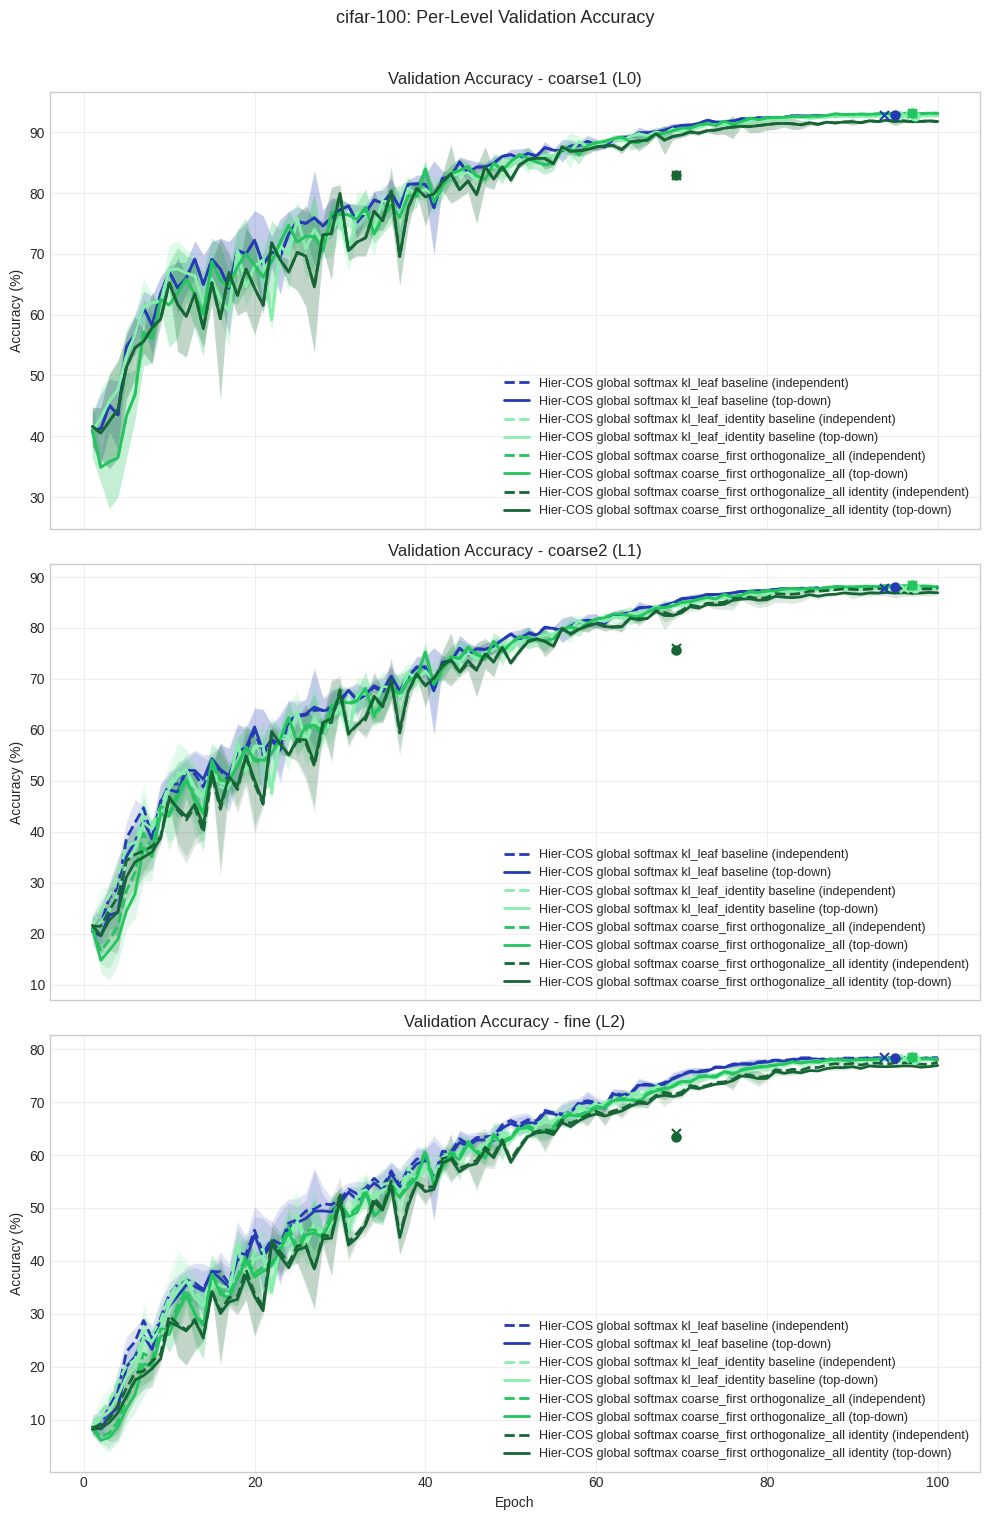

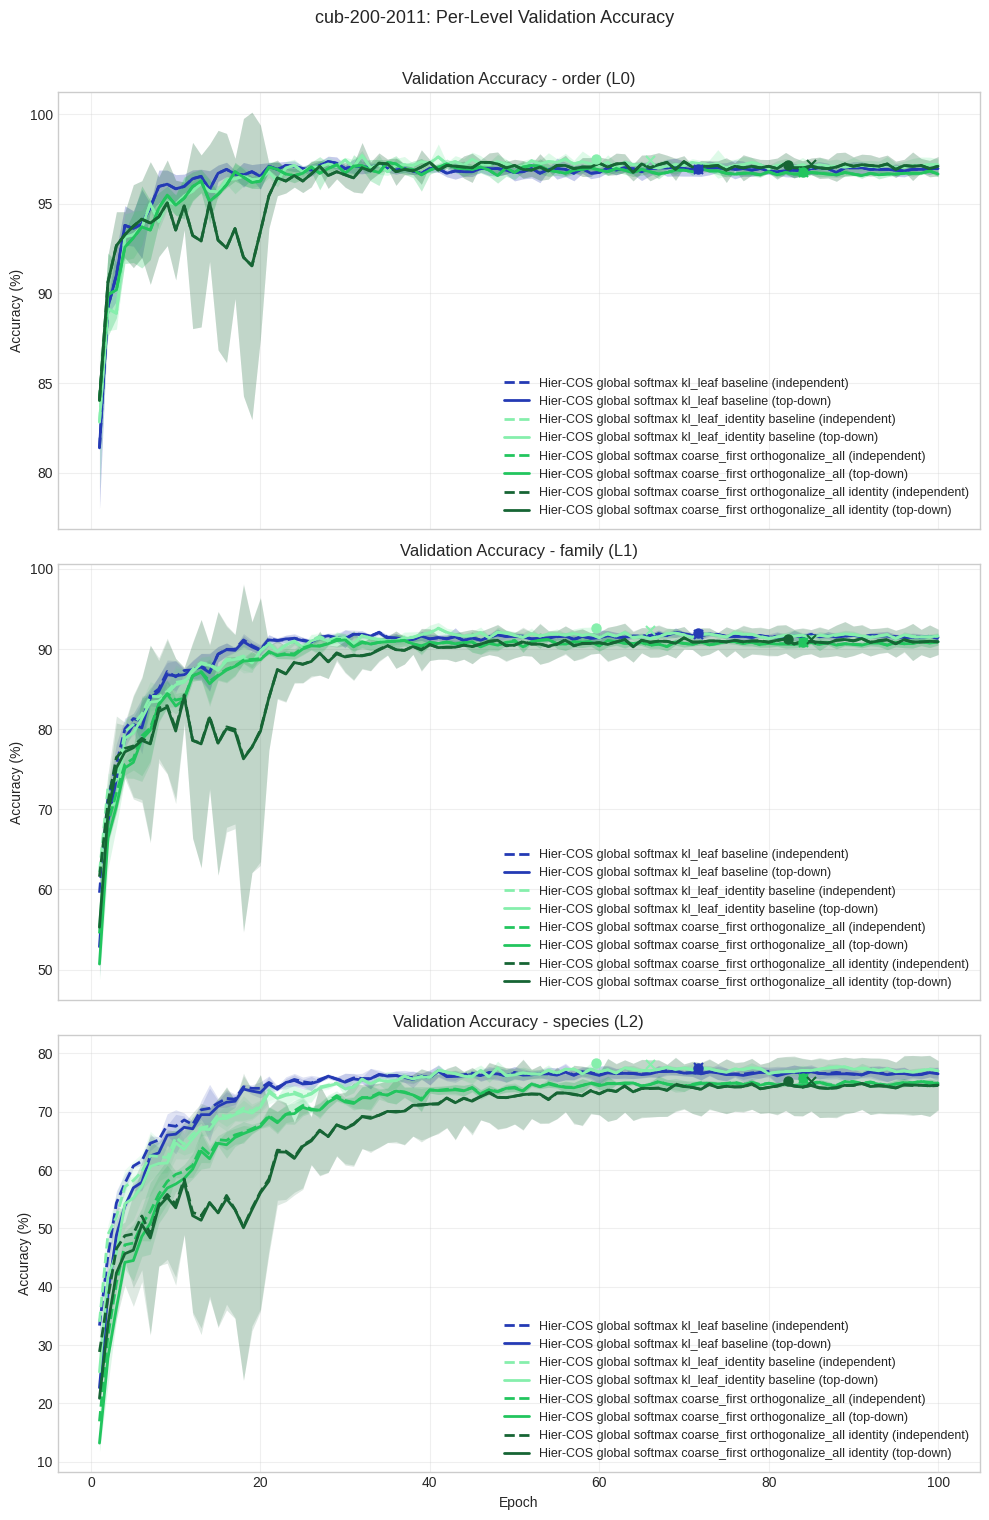

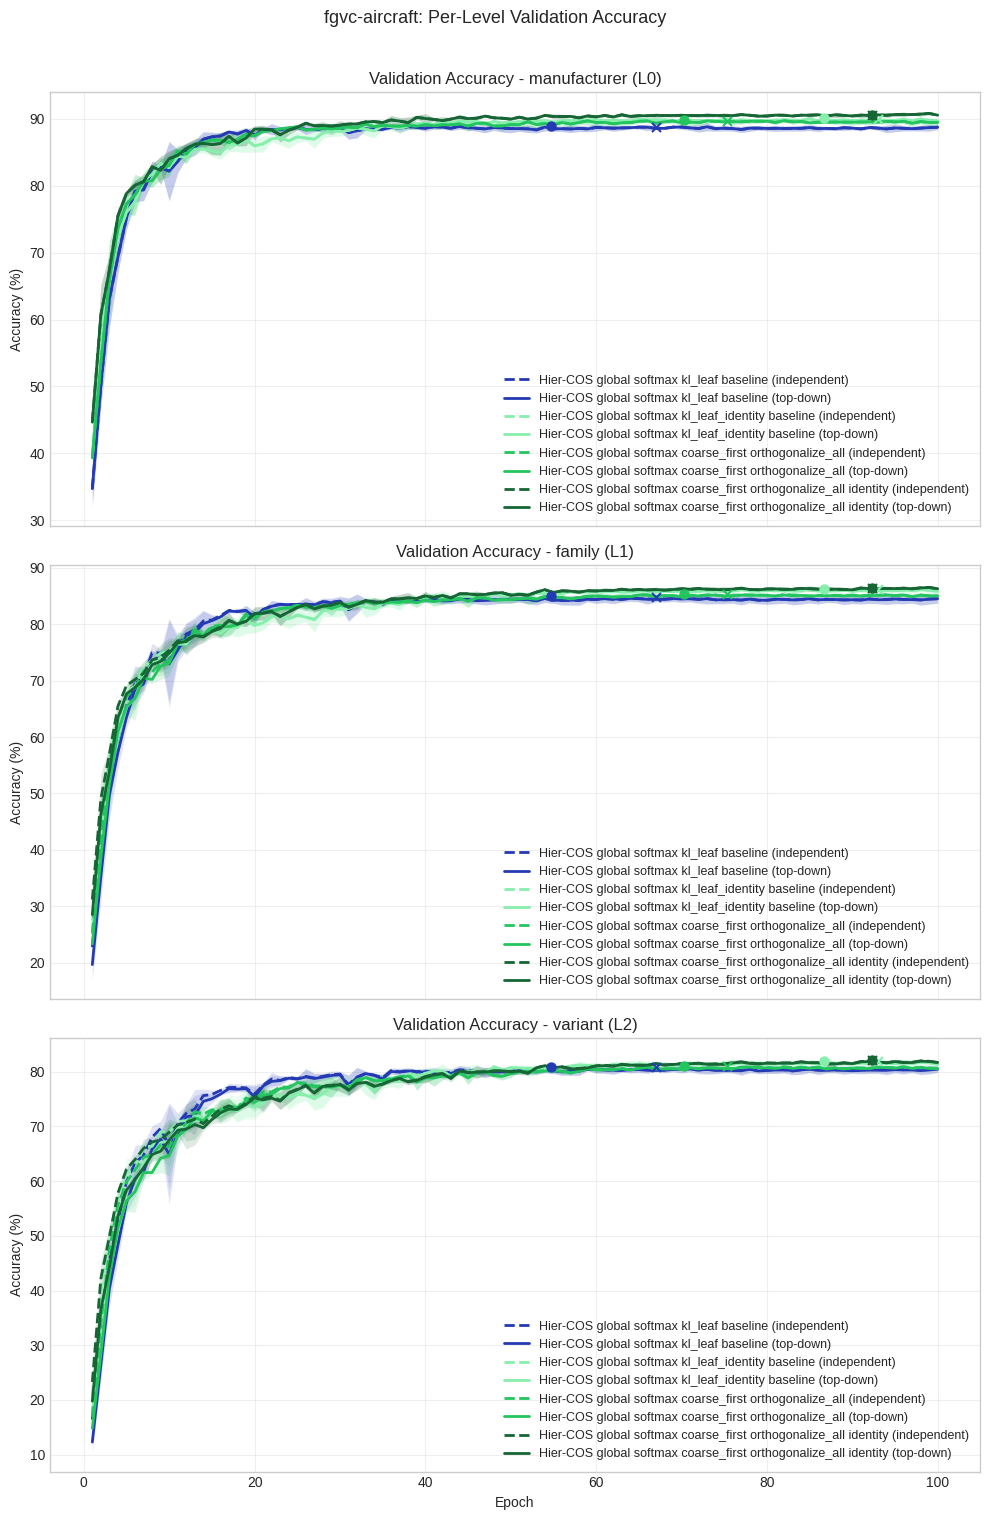

In [19]:
analysis.plot_per_level_validation_accuracy()


Interpretation note:
- In each subplot, solid vs dashed of the same color gives the top-down penalty/gain for that run.
- Across colors, you can compare runs within the same decoding mode by matching line style.
- Larger gaps at deeper levels usually have the strongest impact on final path metrics.

## Final Test Comparison Table

For each dataset, the table compares key test metrics for selected runs and reports deltas versus the first run listed for that dataset (typically the `kl_reg` baseline).


In [20]:
analysis.show_final_test_tables()


### Dataset: `cifar-100`
Baseline run: **Hier-COS global softmax kl_leaf baseline**

| Metric | Hier-COS global softmax kl_leaf baseline (n=3) | Hier-COS global softmax kl_leaf_identity baseline (n=3) | Hier-COS global softmax coarse_first orthogonalize_all (n=3) | Hier-COS global softmax coarse_first orthogonalize_all identity (n=3) |
|---|---:|---:|---:|---:|
| Best epoch (TD/Ind) | 95.0 ± 3.5/93.7 ± 5.0 | 97.3 ± 2.1/96.0 ± 4.4 | 97.0 ± 2.8/97.0 ± 2.8 | 95.0 ± 7.1/95.0 ± 7.1 |
| FPA independent ↑ | **77.50% ± 0.15%** | 76.87% ± 0.45% (-0.63 pp) | <u>77.38% ± 0.20% (-0.12 pp)</u> | 76.05% ± 0.35% (-1.46 pp) |
| FPA top-down ↑ | **77.80% ± 0.24%** | 77.12% ± 0.39% (-0.68 pp) | <u>77.49% ± 0.26% (-0.31 pp)</u> | 76.10% ± 0.31% (-1.70 pp) |
| wAP independent ↑ | **80.05% ± 0.19%** | 79.60% ± 0.45% (-0.46 pp) | <u>79.89% ± 0.16% (-0.16 pp)</u> | 79.08% ± 0.22% (-0.98 pp) |
| wAP top-down ↑ | **80.08% ± 0.22%** | 79.53% ± 0.35% (-0.55 pp) | <u>79.87% ± 0.20% (-0.20 pp)</u> | 78.54% ± 0.35% (-1.54 pp) |
| TICE independent ↓ | 1.05% ± 0.04% | <u>0.97% ± 0.09% (-0.07 pp)</u> | **0.43% ± 0.10% (-0.61 pp)** | 1.07% ± 0.24% (+0.03 pp) |
| TICE top-down ↓ | **0.00% ± 0.00%** | **0.00% ± 0.00% (+0.00 pp)** | **0.00% ± 0.00% (+0.00 pp)** | **0.00% ± 0.00% (+0.00 pp)** |
| AHD independent ↓ | <u>0.444 ± 0.003</u> | 0.449 ± 0.009 (+0.005) | **0.439 ± 0.001 (-0.005)** | 0.473 ± 0.013 (+0.029) |
| AHD top-down ↓ | <u>0.439 ± 0.005</u> | 0.446 ± 0.008 (+0.007) | **0.438 ± 0.001 (-0.001)** | 0.473 ± 0.013 (+0.034) |
| Acc independent coarse1 (L0) ↑ | 91.34% ± 0.06% | <u>91.52% ± 0.23% (+0.18 pp)</u> | **91.61% ± 0.10% (+0.26 pp)** | 90.82% ± 0.43% (-0.52 pp) |
| Acc top-down coarse1 (L0) ↑ | 91.43% ± 0.10% | <u>91.54% ± 0.22% (+0.10 pp)</u> | **91.61% ± 0.10% (+0.17 pp)** | 90.82% ± 0.43% (-0.61 pp) |
| Acc independent coarse2 (L1) ↑ | <u>86.86% ± 0.20%</u> | 86.80% ± 0.32% (-0.05 pp) | **87.12% ± 0.01% (+0.26 pp)** | 86.57% ± 0.28% (-0.29 pp) |
| Acc top-down coarse2 (L1) ↑ | <u>86.91% ± 0.20%</u> | 86.78% ± 0.30% (-0.13 pp) | **87.10% ± 0.01% (+0.19 pp)** | 85.82% ± 0.51% (-1.09 pp) |
| Acc independent fine (L2) ↑ | **77.79% ± 0.20%** | 77.20% ± 0.50% (-0.59 pp) | <u>77.51% ± 0.22% (-0.28 pp)</u> | 76.64% ± 0.19% (-1.15 pp) |
| Acc top-down fine (L2) ↑ | **77.80% ± 0.24%** | 77.12% ± 0.39% (-0.68 pp) | <u>77.49% ± 0.26% (-0.31 pp)</u> | 76.10% ± 0.31% (-1.70 pp) |

### Dataset: `cub-200-2011`
Baseline run: **Hier-COS global softmax kl_leaf baseline**

| Metric | Hier-COS global softmax kl_leaf baseline (n=3) | Hier-COS global softmax kl_leaf_identity baseline (n=3) | Hier-COS global softmax coarse_first orthogonalize_all (n=3) | Hier-COS global softmax coarse_first orthogonalize_all identity (n=3) |
|---|---:|---:|---:|---:|
| Best epoch (TD/Ind) | 71.7 ± 16.3/71.7 ± 16.3 | 59.7 ± 12.0/66.0 ± 15.9 | 84.0 ± 15.1/84.0 ± 15.1 | 82.3 ± 15.0/85.0 ± 10.4 |
| FPA independent ↑ | <u>76.06% ± 0.43%</u> | **76.37% ± 0.36% (+0.31 pp)** | 74.10% ± 0.23% (-1.96 pp) | 73.42% ± 3.20% (-2.64 pp) |
| FPA top-down ↑ | <u>76.12% ± 0.47%</u> | **76.33% ± 0.44% (+0.21 pp)** | 74.14% ± 0.22% (-1.98 pp) | 73.37% ± 3.13% (-2.75 pp) |
| wAP independent ↑ | <u>79.51% ± 0.34%</u> | **79.69% ± 0.30% (+0.18 pp)** | 77.80% ± 0.23% (-1.71 pp) | 77.19% ± 2.80% (-2.32 pp) |
| wAP top-down ↑ | <u>79.36% ± 0.40%</u> | **79.60% ± 0.40% (+0.24 pp)** | 77.73% ± 0.23% (-1.63 pp) | 77.12% ± 2.73% (-2.24 pp) |
| TICE independent ↓ | 0.60% ± 0.19% | <u>0.20% ± 0.09% (-0.41 pp)</u> | 0.32% ± 0.02% (-0.28 pp) | **0.09% ± 0.05% (-0.51 pp)** |
| TICE top-down ↓ | **0.00% ± 0.00%** | **0.00% ± 0.00% (+0.00 pp)** | **0.00% ± 0.00% (+0.00 pp)** | **0.00% ± 0.00% (+0.00 pp)** |
| AHD independent ↓ | <u>0.367 ± 0.006</u> | **0.357 ± 0.007 (-0.011)** | 0.391 ± 0.007 (+0.023) | 0.395 ± 0.052 (+0.028) |
| AHD top-down ↓ | <u>0.366 ± 0.007</u> | **0.358 ± 0.009 (-0.009)** | 0.390 ± 0.007 (+0.024) | 0.397 ± 0.051 (+0.030) |
| Acc independent order (L0) ↑ | 96.83% ± 0.12% | **97.08% ± 0.15% (+0.25 pp)** | 96.68% ± 0.17% (-0.14 pp) | <u>96.86% ± 0.61% (+0.03 pp)</u> |
| Acc top-down order (L0) ↑ | 96.83% ± 0.12% | **97.04% ± 0.19% (+0.21 pp)** | 96.68% ± 0.17% (-0.14 pp) | <u>96.84% ± 0.59% (+0.01 pp)</u> |
| Acc independent family (L1) ↑ | <u>90.48% ± 0.11%</u> | **90.91% ± 0.19% (+0.43 pp)** | 90.16% ± 0.29% (-0.32 pp) | 90.19% ± 1.43% (-0.29 pp) |
| Acc top-down family (L1) ↑ | <u>90.42% ± 0.15%</u> | **90.86% ± 0.27% (+0.45 pp)** | 90.15% ± 0.33% (-0.27 pp) | 90.12% ± 1.37% (-0.30 pp) |
| Acc independent species (L2) ↑ | <u>76.30% ± 0.41%</u> | **76.42% ± 0.34% (+0.13 pp)** | 74.22% ± 0.24% (-2.08 pp) | 73.44% ± 3.20% (-2.86 pp) |
| Acc top-down species (L2) ↑ | <u>76.12% ± 0.47%</u> | **76.33% ± 0.44% (+0.21 pp)** | 74.14% ± 0.22% (-1.98 pp) | 73.37% ± 3.13% (-2.75 pp) |

### Dataset: `fgvc-aircraft`
Baseline run: **Hier-COS global softmax kl_leaf baseline**

| Metric | Hier-COS global softmax kl_leaf baseline (n=3) | Hier-COS global softmax kl_leaf_identity baseline (n=3) | Hier-COS global softmax coarse_first orthogonalize_all (n=3) | Hier-COS global softmax coarse_first orthogonalize_all identity (n=3) |
|---|---:|---:|---:|---:|
| Best epoch (TD/Ind) | 54.7 ± 20.8/67.0 ± 7.2 | 86.7 ± 11.5/93.0 ± 6.0 | 70.3 ± 20.8/75.3 ± 8.3 | 92.3 ± 7.4/92.3 ± 7.4 |
| FPA independent ↑ | 80.68% ± 0.48% | **82.41% ± 0.91% (+1.73 pp)** | 81.41% ± 0.15% (+0.73 pp) | <u>82.27% ± 0.43% (+1.59 pp)</u> |
| FPA top-down ↑ | 80.50% ± 0.24% | **82.45% ± 0.95% (+1.95 pp)** | 81.22% ± 0.26% (+0.72 pp) | <u>82.32% ± 0.41% (+1.82 pp)</u> |
| wAP independent ↑ | 83.39% ± 0.35% | **85.15% ± 0.74% (+1.76 pp)** | 84.18% ± 0.19% (+0.79 pp) | <u>84.93% ± 0.33% (+1.54 pp)</u> |
| wAP top-down ↑ | 83.18% ± 0.12% | **85.12% ± 0.78% (+1.94 pp)** | 83.96% ± 0.12% (+0.78 pp) | <u>84.92% ± 0.34% (+1.74 pp)</u> |
| TICE independent ↓ | 1.05% ± 0.33% | 0.51% ± 0.22% (-0.54 pp) | <u>0.50% ± 0.14% (-0.55 pp)</u> | **0.38% ± 0.08% (-0.67 pp)** |
| TICE top-down ↓ | **0.00% ± 0.00%** | **0.00% ± 0.00% (+0.00 pp)** | **0.00% ± 0.00% (+0.00 pp)** | **0.00% ± 0.00% (+0.00 pp)** |
| AHD independent ↓ | 0.460 ± 0.007 | **0.406 ± 0.021 (-0.054)** | 0.433 ± 0.007 (-0.027) | <u>0.413 ± 0.010 (-0.047)</u> |
| AHD top-down ↓ | 0.461 ± 0.002 | **0.405 ± 0.021 (-0.056)** | 0.438 ± 0.001 (-0.023) | <u>0.412 ± 0.009 (-0.049)</u> |
| Acc independent manufacturer (L0) ↑ | 88.78% ± 0.05% | **90.43% ± 0.50% (+1.65 pp)** | 89.64% ± 0.38% (+0.86 pp) | <u>90.04% ± 0.45% (+1.26 pp)</u> |
| Acc top-down manufacturer (L0) ↑ | 88.82% ± 0.09% | **90.43% ± 0.51% (+1.61 pp)** | 89.46% ± 0.24% (+0.64 pp) | <u>90.04% ± 0.45% (+1.22 pp)</u> |
| Acc independent family (L1) ↑ | 84.70% ± 0.29% | **86.59% ± 0.63% (+1.89 pp)** | 85.71% ± 0.28% (+1.01 pp) | <u>86.48% ± 0.34% (+1.78 pp)</u> |
| Acc top-down family (L1) ↑ | 84.59% ± 0.05% | **86.65% ± 0.66% (+2.06 pp)** | 85.52% ± 0.16% (+0.93 pp) | <u>86.43% ± 0.38% (+1.84 pp)</u> |
| Acc independent variant (L2) ↑ | 80.86% ± 0.50% | **82.56% ± 0.90% (+1.70 pp)** | 81.47% ± 0.15% (+0.61 pp) | <u>82.31% ± 0.41% (+1.45 pp)</u> |
| Acc top-down variant (L2) ↑ | 80.50% ± 0.24% | **82.45% ± 0.95% (+1.95 pp)** | 81.22% ± 0.26% (+0.72 pp) | <u>82.32% ± 0.41% (+1.82 pp)</u> |

Interpretation note:
- Metrics are rows and runs are columns.
- Goal arrows are in metric names: `↑` means maximize, `↓` means minimize.
- Non-baseline run cells show `value (delta vs baseline)`.
- Bold cells mark the best run for each metric in the dataset table.
- Delta is computed as `run - baseline`.
